# An Attention-Enhanced Long Short-Term Memory (LSTM) Network for Predicting ETF Price Movements Using Historical Trading Data

EDA towards the above project topic

In [2]:
# ===========================================
# Phase 1: Data Understanding
# Import Libraries
# ===========================================

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# ===========================================
# Load Dataset
# ===========================================

from google.colab import files

uploaded = files.upload()

Saving MTN.xlsx to MTN.xlsx


In [4]:
# Read the dataset
df = pd.read_excel("MTN.xlsx")

# Display first five rows
df.head()

,Daily Date,Share Code,Year High (GH¢),Year Low (GH¢),Previous Closing Price - VWAP (GH¢),Opening Price (GH¢),Last Transaction Price (GH¢),Closing Price - VWAP (GH¢),Price Change (GH¢),Closing Bid Price (GH¢),Closing Offer Price (GH¢),Total Shares Traded,Total Value Traded (GH¢)
0,29/05/2026,MTNGH,6.8,4.2,6.51,6.51,6.50,6.50,-0.01,NaN,6.50,2439096.0,15854234.33
1,28/05/2026,MTNGH,6.8,4.2,6.51,6.51,6.51,6.51,0.00,6.65,6.73,4541021.0,29550112.89
2,26/05/2026,MTNGH,6.8,4.2,6.73,6.73,6.50,6.51,-0.22,6.73,6.79,8837231.0,57559488.93
3,25/05/2026,MTNGH,6.8,4.2,6.73,6.73,6.73,6.73,0.00,6.73,6.79,411899.0,2771377.12
4,22/05/2026,MTNGH,6.8,4.2,6.73,6.73,6.73,6.73,0.00,6.72,6.73,1776101.0,11955854.47


In [5]:
# ===========================================
# Dataset Dimensions
# ===========================================

rows, cols = df.shape

print(f"Number of Rows    : {rows}")
print(f"Number of Columns : {cols}")

Number of Rows    : 1904
Number of Columns : 13


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1904 entries, 0 to 1903
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Daily Date                           1904 non-null   object 
 1   Share Code                           1904 non-null   object 
 2   Year High (GH¢)                      1904 non-null   float64
 3   Year Low (GH¢)                       1904 non-null   float64
 4   Previous Closing Price - VWAP (GH¢)  1904 non-null   float64
 5   Opening Price (GH¢)                  1902 non-null   float64
 6   Last Transaction Price (GH¢)         1904 non-null   float64
 7   Closing Price - VWAP (GH¢)           1902 non-null   float64
 8   Price Change (GH¢)                   1904 non-null   float64
 9   Closing Bid Price (GH¢)              1762 non-null   float64
 10  Closing Offer Price (GH¢)            1797 non-null   float64
 11  Total Shares Traded           

In [7]:
print(df.columns.tolist())

['Daily Date', 'Share Code', 'Year High (GH¢)', 'Year Low (GH¢)', 'Previous Closing Price - VWAP (GH¢)', 'Opening Price (GH¢)', 'Last Transaction Price (GH¢)', 'Closing Price - VWAP (GH¢)', 'Price Change (GH¢)', 'Closing Bid Price (GH¢)', 'Closing Offer Price (GH¢)', 'Total Shares Traded', 'Total Value Traded (GH¢)']


In [8]:
df.dtypes

,0
Daily Date,object
Share Code,object
Year High (GH¢),float64
Year Low (GH¢),float64
Previous Closing Price - VWAP (GH¢),float64
Opening Price (GH¢),float64
Last Transaction Price (GH¢),float64
Closing Price - VWAP (GH¢),float64
Price Change (GH¢),float64
Closing Bid Price (GH¢),float64


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year High (GH¢),1904.0,1.562943e+01,4.288205e+02,0.57,0.80,1.200,1.820000e+00,1.323618e+04
Year Low (GH¢),1904.0,5.217962e+01,1.599032e+03,0.55,0.67,0.820,1.390000e+00,5.757736e+04
Previous Closing Price - VWAP (GH¢),1904.0,1.614417e+00,1.318459e+00,0.00,0.73,1.090,1.810000e+00,6.800000e+00
Opening Price (GH¢),1902.0,1.616220e+00,1.318076e+00,0.55,0.73,1.095,1.810000e+00,6.800000e+00
Last Transaction Price (GH¢),1904.0,1.619249e+00,1.326736e+00,0.08,0.73,1.090,1.810000e+00,6.800000e+00
Closing Price - VWAP (GH¢),1902.0,1.619306e+00,1.322822e+00,0.55,0.73,1.095,1.810000e+00,6.800000e+00
Price Change (GH¢),1904.0,6.534611e-03,1.056829e-01,-0.59,0.00,0.000,0.000000e+00,4.120000e+00
Closing Bid Price (GH¢),1762.0,1.606277e+00,1.326285e+00,0.00,0.72,1.080,2.017500e+00,8.000000e+00
Closing Offer Price (GH¢),1797.0,1.607518e+00,1.389432e+00,0.00,0.73,1.100,1.800000e+00,9.000000e+00
Total Shares Traded,1902.0,2.013267e+06,1.090720e+07,0.00,9971.50,61955.500,6.290728e+05,2.650561e+08


In [10]:
# ===========================================
# Missing Values
# ===========================================

missing = df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

,0
Closing Bid Price (GH¢),142
Closing Offer Price (GH¢),107
Total Value Traded (GH¢),56
Opening Price (GH¢),2
Closing Price - VWAP (GH¢),2
Total Shares Traded,2


In [11]:
missing_df = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing_df = missing_df[missing_df["Missing Values"]>0]

missing_df.sort_values(
    by="Missing Values",
    ascending=False
)

,Missing Values,Percentage
Closing Bid Price (GH¢),142,7.457983
Closing Offer Price (GH¢),107,5.619748
Total Value Traded (GH¢),56,2.941176
Opening Price (GH¢),2,0.105042
Closing Price - VWAP (GH¢),2,0.105042
Total Shares Traded,2,0.105042


In [12]:
# ===========================================
# Duplicate Rows
# ===========================================

duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 3


In [13]:
# ===========================================
# Convert Date Column
# ===========================================

df["Daily Date"] = pd.to_datetime(df["Daily Date"])

print("Start Date :", df["Daily Date"].min())
print("End Date   :", df["Daily Date"].max())

Start Date : 2018-09-05 00:00:00
End Date   : 2026-05-29 00:00:00


/tmp/ipykernel_596/2247154119.py:5: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Daily Date"] = pd.to_datetime(df["Daily Date"])


In [14]:
# ===========================================
# Sort Dataset
# ===========================================

df = df.sort_values("Daily Date")

df.reset_index(drop=True, inplace=True)

df.head()

,Daily Date,Share Code,Year High (GH¢),Year Low (GH¢),Previous Closing Price - VWAP (GH¢),Opening Price (GH¢),Last Transaction Price (GH¢),Closing Price - VWAP (GH¢),Price Change (GH¢),Closing Bid Price (GH¢),Closing Offer Price (GH¢),Total Shares Traded,Total Value Traded (GH¢)
0,2018-09-05,MTNGH,0.75,0.75,0.75,0.75,0.75,0.75,0.00,0.75,NaN,5007600.0,NaN
1,2018-09-06,MTNGH,0.75,0.75,0.75,0.75,0.75,0.75,0.00,0.75,NaN,0.0,NaN
2,2018-09-07,MTNGH,0.75,0.75,0.75,0.75,0.75,0.75,0.00,0.75,NaN,0.0,NaN
3,2018-09-10,MTNGH,0.75,0.75,0.75,0.75,0.75,0.75,0.00,0.75,NaN,720000.0,NaN
4,2018-09-11,MTNGH,0.76,0.75,0.75,0.75,0.77,0.76,0.01,0.76,0.77,565900.0,NaN


In [15]:
# ===========================================
# Unique Share Codes
# ===========================================

df["Share Code"].value_counts()

,count
Share Code,
MTNGH,1904


In [16]:
# ===========================================
# Data Quality Summary
# ===========================================

report = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Missing (%)": round(df.isnull().mean()*100,2),
    "Unique Values": df.nunique()
})

report

,Data Type,Missing Values,Missing (%),Unique Values
Daily Date,datetime64[ns],0,0.00,1893
Share Code,object,0,0.00,1
Year High (GH¢),float64,0,0.00,135
Year Low (GH¢),float64,0,0.00,36
Previous Closing Price - VWAP (GH¢),float64,0,0.00,270
Opening Price (GH¢),float64,2,0.11,270
Last Transaction Price (GH¢),float64,0,0.00,253
Closing Price - VWAP (GH¢),float64,2,0.11,269
Price Change (GH¢),float64,0,0.00,51
Closing Bid Price (GH¢),float64,142,7.46,252


In [17]:
print("="*60)
print("DATASET ASSESSMENT")
print("="*60)

print(f"Number of observations : {len(df)}")
print(f"Number of features     : {df.shape[1]}")
print(f"Duplicate rows         : {df.duplicated().sum()}")
print(f"Missing values         : {df.isnull().sum().sum()}")

print("\nDataset appears suitable for multivariate")
print("time-series forecasting using deep learning.")

DATASET ASSESSMENT
Number of observations : 1904
Number of features     : 13
Duplicate rows         : 3
Missing values         : 311

Dataset appears suitable for multivariate
time-series forecasting using deep learning.


In [18]:
# ===========================================
# Create a Working Copy
# ===========================================

df_clean = df.copy()

print("Working copy created successfully.")

Working copy created successfully.


In [19]:
# ===========================================
# Missing Values
# ===========================================

missing = pd.DataFrame({
    "Missing Values": df_clean.isnull().sum(),
    "Percentage (%)": round(df_clean.isnull().mean()*100,2)
})

missing[missing["Missing Values"]>0]

,Missing Values,Percentage (%)
Opening Price (GH¢),2,0.11
Closing Price - VWAP (GH¢),2,0.11
Closing Bid Price (GH¢),142,7.46
Closing Offer Price (GH¢),107,5.62
Total Shares Traded,2,0.11
Total Value Traded (GH¢),56,2.94


In [20]:
# ===========================================
# Remove Duplicate Rows
# ===========================================

print("Rows before:", len(df_clean))

df_clean = df_clean.drop_duplicates()

print("Rows after :", len(df_clean))
print("Duplicates removed:",
      df.duplicated().sum())

Rows before: 1904
Rows after : 1901
Duplicates removed: 3


In [21]:
# ===========================================
# Convert Date
# ===========================================

df_clean["Daily Date"] = pd.to_datetime(
    df_clean["Daily Date"]
)

df_clean.dtypes

,0
Daily Date,datetime64[ns]
Share Code,object
Year High (GH¢),float64
Year Low (GH¢),float64
Previous Closing Price - VWAP (GH¢),float64
Opening Price (GH¢),float64
Last Transaction Price (GH¢),float64
Closing Price - VWAP (GH¢),float64
Price Change (GH¢),float64
Closing Bid Price (GH¢),float64


In [22]:
# ===========================================
# Sort by Date
# ===========================================

df_clean = df_clean.sort_values("Daily Date")

df_clean.reset_index(drop=True,
                     inplace=True)

In [23]:
df_clean.head()

,Daily Date,Share Code,Year High (GH¢),Year Low (GH¢),Previous Closing Price - VWAP (GH¢),Opening Price (GH¢),Last Transaction Price (GH¢),Closing Price - VWAP (GH¢),Price Change (GH¢),Closing Bid Price (GH¢),Closing Offer Price (GH¢),Total Shares Traded,Total Value Traded (GH¢)
0,2018-09-05,MTNGH,0.75,0.75,0.75,0.75,0.75,0.75,0.00,0.75,NaN,5007600.0,NaN
1,2018-09-06,MTNGH,0.75,0.75,0.75,0.75,0.75,0.75,0.00,0.75,NaN,0.0,NaN
2,2018-09-07,MTNGH,0.75,0.75,0.75,0.75,0.75,0.75,0.00,0.75,NaN,0.0,NaN
3,2018-09-10,MTNGH,0.75,0.75,0.75,0.75,0.75,0.75,0.00,0.75,NaN,720000.0,NaN
4,2018-09-11,MTNGH,0.76,0.75,0.75,0.75,0.77,0.76,0.01,0.76,0.77,565900.0,NaN


In [24]:
# ===========================================
# Drop Columns
# ===========================================

df_clean.drop(
    columns=[
        "Closing Bid Price (GH¢)",
        "Closing Offer Price (GH¢)"
    ],
    inplace=True
)

df_clean.columns

Index(['Daily Date', 'Share Code', 'Year High (GH¢)', 'Year Low (GH¢)',
       'Previous Closing Price - VWAP (GH¢)', 'Opening Price (GH¢)',
       'Last Transaction Price (GH¢)', 'Closing Price - VWAP (GH¢)',
       'Price Change (GH¢)', 'Total Shares Traded',
       'Total Value Traded (GH¢)'],
      dtype='object')

In [25]:
# ===========================================
# Interpolate Price Variables
# ===========================================

price_columns = [
    "Opening Price (GH¢)",
    "Closing Price - VWAP (GH¢)"
]

df_clean[price_columns] = (
    df_clean[price_columns]
    .interpolate(method="linear")
)

In [26]:
# ===========================================
# Fill Trading Variables
# ===========================================

df_clean["Total Shares Traded"] = (
    df_clean["Total Shares Traded"]
    .ffill()
)

df_clean["Total Value Traded (GH¢)"] = (
    df_clean["Total Value Traded (GH¢)"]
    .ffill()
)

In [27]:
# ===========================================
# Check Missing Values Again
# ===========================================

df_clean.isnull().sum()

,0
Daily Date,0
Share Code,0
Year High (GH¢),0
Year Low (GH¢),0
Previous Closing Price - VWAP (GH¢),0
Opening Price (GH¢),0
Last Transaction Price (GH¢),0
Closing Price - VWAP (GH¢),0
Price Change (GH¢),0
Total Shares Traded,0


In [28]:
# ===========================================
# Final Dataset
# ===========================================

print(df_clean.shape)

df_clean.head()

(1901, 11)


,Daily Date,Share Code,Year High (GH¢),Year Low (GH¢),Previous Closing Price - VWAP (GH¢),Opening Price (GH¢),Last Transaction Price (GH¢),Closing Price - VWAP (GH¢),Price Change (GH¢),Total Shares Traded,Total Value Traded (GH¢)
0,2018-09-05,MTNGH,0.75,0.75,0.75,0.75,0.75,0.75,0.00,5007600.0,NaN
1,2018-09-06,MTNGH,0.75,0.75,0.75,0.75,0.75,0.75,0.00,0.0,NaN
2,2018-09-07,MTNGH,0.75,0.75,0.75,0.75,0.75,0.75,0.00,0.0,NaN
3,2018-09-10,MTNGH,0.75,0.75,0.75,0.75,0.75,0.75,0.00,720000.0,NaN
4,2018-09-11,MTNGH,0.76,0.75,0.75,0.75,0.77,0.76,0.01,565900.0,NaN


In [29]:
# ===========================================
# Save Clean Dataset
# ===========================================

df_clean.to_csv(
    "MTN_Clean.csv",
    index=False
)

print("Dataset saved successfully.")

Dataset saved successfully.


In [30]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1901 entries, 0 to 1900
Data columns (total 11 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   Daily Date                           1901 non-null   datetime64[ns]
 1   Share Code                           1901 non-null   object        
 2   Year High (GH¢)                      1901 non-null   float64       
 3   Year Low (GH¢)                       1901 non-null   float64       
 4   Previous Closing Price - VWAP (GH¢)  1901 non-null   float64       
 5   Opening Price (GH¢)                  1901 non-null   float64       
 6   Last Transaction Price (GH¢)         1901 non-null   float64       
 7   Closing Price - VWAP (GH¢)           1901 non-null   float64       
 8   Price Change (GH¢)                   1901 non-null   float64       
 9   Total Shares Traded                  1901 non-null   float64       
 10  Total Value 

In [31]:
df_clean.describe().T

,count,mean,min,25%,50%,75%,max,std
Daily Date,1901,2022-07-17 19:06:05.491846400,2018-09-05 00:00:00,2020-08-06 00:00:00,2022-07-20 00:00:00,2024-07-01 00:00:00,2026-05-29 00:00:00,NaN
Year High (GH¢),1901.0,15.652404,0.57,0.8,1.2,1.85,13236.18,429.158558
Year Low (GH¢),1901.0,52.260784,0.55,0.67,0.82,1.39,57577.36,1600.292444
Previous Closing Price - VWAP (GH¢),1901.0,1.615471,0.0,0.73,1.09,1.81,6.8,1.3192
Opening Price (GH¢),1901.0,1.619445,0.55,0.73,1.1,1.81,6.8,1.319993
Last Transaction Price (GH¢),1901.0,1.62031,0.08,0.73,1.09,1.81,6.8,1.327482
Closing Price - VWAP (GH¢),1901.0,1.622572,0.55,0.73,1.1,1.85,6.8,1.32481
Price Change (GH¢),1901.0,0.006545,-0.59,0.0,0.0,0.0,4.12,0.105766
Total Shares Traded,1901.0,2015138.772278,0.0,9962.0,62053.0,626480.0,265056095.0,10910376.011469
Total Value Traded (GH¢),1849.0,3509836.00483,0.0,11049.0,72659.52,1170913.7,514295298.74,19700913.218076


In [32]:
df_clean.isnull().sum()

,0
Daily Date,0
Share Code,0
Year High (GH¢),0
Year Low (GH¢),0
Previous Closing Price - VWAP (GH¢),0
Opening Price (GH¢),0
Last Transaction Price (GH¢),0
Closing Price - VWAP (GH¢),0
Price Change (GH¢),0
Total Shares Traded,0


In [33]:
df_clean.duplicated().sum()

np.int64(0)

In [34]:
df_clean["Total Value Traded (GH¢)"].isnull().sum()

np.int64(52)

In [35]:
# Display rows with missing Total Value Traded
df_clean[df_clean["Total Value Traded (GH¢)"].isnull()]

,Daily Date,Share Code,Year High (GH¢),Year Low (GH¢),Previous Closing Price - VWAP (GH¢),Opening Price (GH¢),Last Transaction Price (GH¢),Closing Price - VWAP (GH¢),Price Change (GH¢),Total Shares Traded,Total Value Traded (GH¢)
0,2018-09-05,MTNGH,0.75,0.75,0.75,0.75,0.75,0.75,0.00,5007600.0,NaN
1,2018-09-06,MTNGH,0.75,0.75,0.75,0.75,0.75,0.75,0.00,0.0,NaN
2,2018-09-07,MTNGH,0.75,0.75,0.75,0.75,0.75,0.75,0.00,0.0,NaN
3,2018-09-10,MTNGH,0.75,0.75,0.75,0.75,0.75,0.75,0.00,720000.0,NaN
4,2018-09-11,MTNGH,0.76,0.75,0.75,0.75,0.77,0.76,0.01,565900.0,NaN
5,2018-09-12,MTNGH,0.76,0.75,0.76,0.76,0.77,0.76,0.00,3000.0,NaN
6,2018-09-13,MTNGH,0.77,0.75,0.76,0.76,0.77,0.77,0.01,156800.0,NaN
7,2018-09-14,MTNGH,0.78,0.75,0.77,0.77,0.78,0.78,0.01,266000.0,NaN
8,2018-09-17,MTNGH,0.80,0.75,0.78,0.78,0.80,0.80,0.02,1311900.0,NaN
9,2018-09-18,MTNGH,0.80,0.75,0.80,0.80,0.80,0.80,0.00,861900.0,NaN


In [36]:
# Display only the dates of missing values
df_clean.loc[
    df_clean["Total Value Traded (GH¢)"].isnull(),
    ["Daily Date", "Total Value Traded (GH¢)"]
]

,Daily Date,Total Value Traded (GH¢)
0,2018-09-05,NaN
1,2018-09-06,NaN
2,2018-09-07,NaN
3,2018-09-10,NaN
4,2018-09-11,NaN
5,2018-09-12,NaN
6,2018-09-13,NaN
7,2018-09-14,NaN
8,2018-09-17,NaN
9,2018-09-18,NaN


In [37]:
# Fill missing Total Value Traded using Closing Price × Total Shares Traded

mask = df_clean["Total Value Traded (GH¢)"].isnull()

df_clean.loc[mask, "Total Value Traded (GH¢)"] = (
    df_clean.loc[mask, "Closing Price - VWAP (GH¢)"] *
    df_clean.loc[mask, "Total Shares Traded"]
)

In [38]:
df_clean["Total Value Traded (GH¢)"].isnull().sum()

np.int64(0)

In [39]:
# Top 10 highest Year High values
df_clean.nlargest(10, "Year High (GH¢)")

,Daily Date,Share Code,Year High (GH¢),Year Low (GH¢),Previous Closing Price - VWAP (GH¢),Opening Price (GH¢),Last Transaction Price (GH¢),Closing Price - VWAP (GH¢),Price Change (GH¢),Total Shares Traded,Total Value Traded (GH¢)
1685,2025-07-18,MTNGH,13236.18,39443.80,0.00,3.005,0.24,3.005,0.5831,6638283.0,19785617.03
1737,2025-09-30,MTNGH,13236.18,57577.36,0.00,4.350,0.08,4.425,0.5488,548107.0,2384265.45
1881,2026-04-30,MTNGH,6.80,4.20,6.77,6.770,6.80,6.800,0.0300,3059292.0,20799960.25
1882,2026-05-04,MTNGH,6.80,4.20,6.80,6.800,6.80,6.800,0.0000,705610.0,4801210.06
1883,2026-05-05,MTNGH,6.80,4.20,6.80,6.800,6.80,6.800,0.0000,479619.0,3259635.36
1884,2026-05-06,MTNGH,6.80,4.20,6.80,6.800,6.80,6.800,0.0000,2946136.0,20028741.81
1885,2026-05-07,MTNGH,6.80,4.20,6.80,6.800,6.60,6.770,-0.0300,1384573.0,9373253.53
1886,2026-05-08,MTNGH,6.80,4.20,6.77,6.770,6.60,6.530,-0.2400,2478506.0,16199254.61
1887,2026-05-11,MTNGH,6.80,4.20,6.53,6.530,6.70,6.640,0.1100,304611.0,2021646.03
1888,2026-05-12,MTNGH,6.80,4.20,6.64,6.640,6.80,6.710,0.0700,252217.0,1690732.35


In [40]:
# Top 10 highest Year Low values
df_clean.nlargest(10, "Year Low (GH¢)")

,Daily Date,Share Code,Year High (GH¢),Year Low (GH¢),Previous Closing Price - VWAP (GH¢),Opening Price (GH¢),Last Transaction Price (GH¢),Closing Price - VWAP (GH¢),Price Change (GH¢),Total Shares Traded,Total Value Traded (GH¢)
1737,2025-09-30,MTNGH,13236.18,57577.36,0.00,4.350,0.08,4.425,0.5488,548107.0,2384265.45
1685,2025-07-18,MTNGH,13236.18,39443.80,0.00,3.005,0.24,3.005,0.5831,6638283.0,19785617.03
1802,2026-01-02,MTNGH,4.20,4.20,4.20,4.200,4.20,4.200,0.0000,648197.0,2722427.40
1803,2026-01-05,MTNGH,4.21,4.20,4.20,4.200,4.21,4.210,0.0100,485319.0,2043235.46
1804,2026-01-06,MTNGH,4.21,4.20,4.21,4.210,4.20,4.200,-0.0100,18325232.0,76967682.54
1805,2026-01-07,MTNGH,4.21,4.20,4.20,4.200,4.20,4.200,0.0000,1177361.0,4945126.20
1806,2026-01-08,MTNGH,4.21,4.20,4.20,4.200,4.21,4.210,0.0100,7521.0,31663.41
1807,2026-01-12,MTNGH,4.23,4.20,4.21,4.210,4.23,4.230,0.0200,9416457.0,37550613.33
1809,2026-01-14,MTNGH,4.23,4.20,4.23,4.230,4.23,4.230,0.0000,546941.0,4033240.76
1810,2026-01-15,MTNGH,4.25,4.20,4.23,4.230,4.23,4.250,0.0200,3591791.0,15253121.99


In [41]:
# Around 2025-07-18
df_clean.loc[1683:1687]

,Daily Date,Share Code,Year High (GH¢),Year Low (GH¢),Previous Closing Price - VWAP (GH¢),Opening Price (GH¢),Last Transaction Price (GH¢),Closing Price - VWAP (GH¢),Price Change (GH¢),Total Shares Traded,Total Value Traded (GH¢)
1683,2025-07-17,MTNGH,3.54,2.5,3.03,3.030,3.03,3.030,0.0000,98944.0,299800.32
1684,2025-07-18,MTNGH,3.54,2.5,3.03,3.030,3.04,2.980,-0.0500,6638283.0,19785617.03
1685,2025-07-18,MTNGH,13236.18,39443.8,0.00,3.005,0.24,3.005,0.5831,6638283.0,19785617.03
1686,2025-07-21,MTNGH,3.54,2.5,2.98,2.980,3.03,3.030,0.0500,5028816.0,15237428.12
1687,2025-07-22,MTNGH,3.54,2.5,3.03,3.030,3.03,3.030,0.0000,33783.0,102362.49


In [42]:
# Around 2025-09-30
df_clean.loc[1735:1739]

,Daily Date,Share Code,Year High (GH¢),Year Low (GH¢),Previous Closing Price - VWAP (GH¢),Opening Price (GH¢),Last Transaction Price (GH¢),Closing Price - VWAP (GH¢),Price Change (GH¢),Total Shares Traded,Total Value Traded (GH¢)
1735,2025-09-29,MTNGH,4.35,2.50,4.35,4.35,4.35,4.350,0.0000,1788711.0,7780952.85
1736,2025-09-30,MTNGH,4.35,2.50,4.35,4.35,4.35,4.350,0.0000,548107.0,2384265.45
1737,2025-09-30,MTNGH,13236.18,57577.36,0.00,4.35,0.08,4.425,0.5488,548107.0,2384265.45
1738,2025-10-01,MTNGH,4.50,2.50,4.35,4.35,4.50,4.500,0.1500,505273.0,2272049.33
1739,2025-10-02,MTNGH,4.50,2.50,4.50,4.50,4.50,4.500,0.0000,1384170.0,6231161.20


In [43]:
# Remove corrupted duplicate records
df_clean = df_clean.drop(index=[1685, 1737])

# Reset the index
df_clean = df_clean.reset_index(drop=True)

In [44]:
print(df_clean.shape)
print("Duplicate rows:", df_clean.duplicated().sum())

(1899, 11)
Duplicate rows: 0


In [45]:
df_clean.describe().T

,count,mean,min,25%,50%,75%,max,std
Daily Date,1899,2022-07-16 14:27:29.289099520,2018-09-05 00:00:00,2020-08-05 12:00:00,2022-07-19 00:00:00,2024-06-27 12:00:00,2026-05-29 00:00:00,NaN
Year High (GH¢),1899.0,1.728731,0.57,0.8,1.2,1.81,6.8,1.372033
Year Low (GH¢),1899.0,1.225166,0.55,0.67,0.82,1.39,4.2,0.923941
Previous Closing Price - VWAP (GH¢),1899.0,1.617172,0.55,0.73,1.1,1.81,6.8,1.318851
Opening Price (GH¢),1899.0,1.617278,0.55,0.73,1.1,1.81,6.8,1.318815
Last Transaction Price (GH¢),1899.0,1.621848,0.55,0.73,1.09,1.81,6.8,1.327331
Closing Price - VWAP (GH¢),1899.0,1.620369,0.55,0.73,1.1,1.81,6.8,1.323564
Price Change (GH¢),1899.0,0.005956,-0.59,0.0,0.0,0.0,4.12,0.104249
Total Shares Traded,1899.0,2013476.785729,0.0,9931.0,61858.0,617091.5,265056095.0,10915554.974022
Total Value Traded (GH¢),1899.0,3412400.227725,0.0,10213.86,68788.3,1063117.55,514295298.74,19443605.420198


In [46]:
# Plot settings
plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (12,6)

# EDA ANALYSIS

In [47]:
# ===========================================
# Dataset Shape
# ===========================================

print(f"Rows: {df_clean.shape[0]}")
print(f"Columns: {df_clean.shape[1]}")

Rows: 1899
Columns: 11


In [48]:
# ===========================================
# Date Range
# ===========================================

print("Start Date:", df_clean["Daily Date"].min())
print("End Date:", df_clean["Daily Date"].max())

Start Date: 2018-09-05 00:00:00
End Date: 2026-05-29 00:00:00


In [49]:
# ===========================================
# Unique Companies
# ===========================================

df_clean["Share Code"].value_counts()

,count
Share Code,
MTNGH,1899


In [50]:
# ===========================================
# Variable Summary
# ===========================================

overview = pd.DataFrame({
    "Data Type": df_clean.dtypes,
    "Missing Values": df_clean.isnull().sum(),
    "Unique Values": df_clean.nunique()
})

overview

,Data Type,Missing Values,Unique Values
Daily Date,datetime64[ns],0,1893
Share Code,object,0,1
Year High (GH¢),float64,0,134
Year Low (GH¢),float64,0,34
Previous Closing Price - VWAP (GH¢),float64,0,269
Opening Price (GH¢),float64,0,270
Last Transaction Price (GH¢),float64,0,251
Closing Price - VWAP (GH¢),float64,0,269
Price Change (GH¢),float64,0,49
Total Shares Traded,float64,0,1689


In [53]:
from google.colab import sheets

# Convert the 'Data Type' column to string to handle non-JSON-serializable dtype objects
overview_for_sheet = overview.copy()
overview_for_sheet["Data Type"] = overview_for_sheet["Data Type"].astype(str)

sheet = sheets.InteractiveSheet(df=overview_for_sheet)

https://docs.google.com/spreadsheets/d/1bv7FbkLItTAaacm2GscwYlSyjXOWNJKqJ2OHuniFuaA/edit#gid=0


# Interpretation
The cleaned dataset contains 1,899 daily trading observations of MTN Ghana stock covering the period from 5 September 2018 to 29 May 2026. The dataset comprises 11 variables, including market prices, trading activity, and derived financial indicators. Following preprocessing, all missing values and duplicate records were removed, resulting in a complete dataset suitable for time-series forecasting. The variables consist of one datetime attribute, one categorical identifier (Share Code), and nine numerical attributes representing stock prices and trading activity.

# Stock Price Trend Analysis
Objective

To understand how MTN Ghana's stock prices evolved over time, identify trends, turning points, and market behavior that may influence the forecasting model.

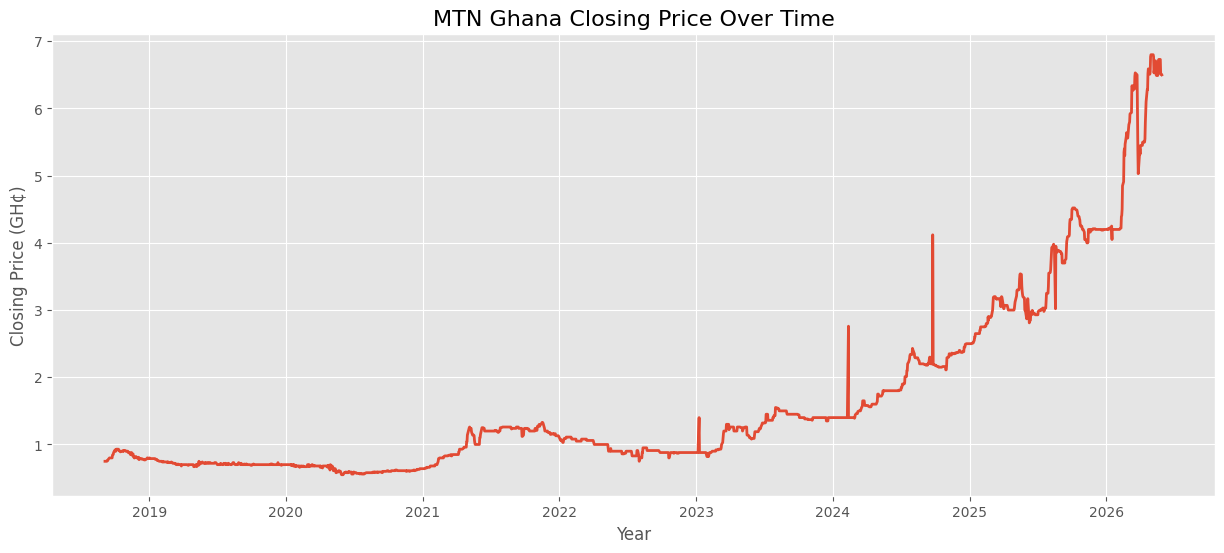

In [54]:
# ===========================================
# Closing Price Trend
# ===========================================

plt.figure(figsize=(15,6))

plt.plot(
    df_clean["Daily Date"],
    df_clean["Closing Price - VWAP (GH¢)"],
    linewidth=2
)

plt.title("MTN Ghana Closing Price Over Time", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Closing Price (GH¢)")
plt.grid(True)

plt.show()

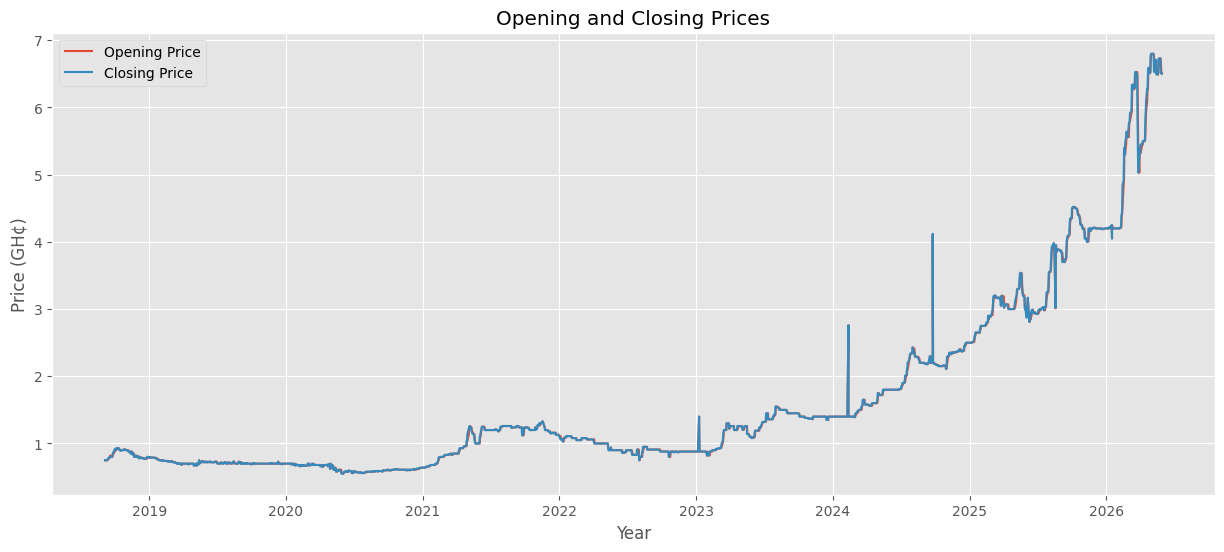

In [57]:
# ===========================================
# Opening vs Closing Price
# ===========================================

plt.figure(figsize=(15,6))

plt.plot(
    df_clean["Daily Date"],
    df_clean["Opening Price (GH¢)"],
    label="Opening Price"
)

plt.plot(
    df_clean["Daily Date"],
    df_clean["Closing Price - VWAP (GH¢)"],
    label="Closing Price"
)

plt.title("Opening and Closing Prices")
plt.xlabel("Year")
plt.ylabel("Price (GH¢)")
plt.legend()

plt.show()

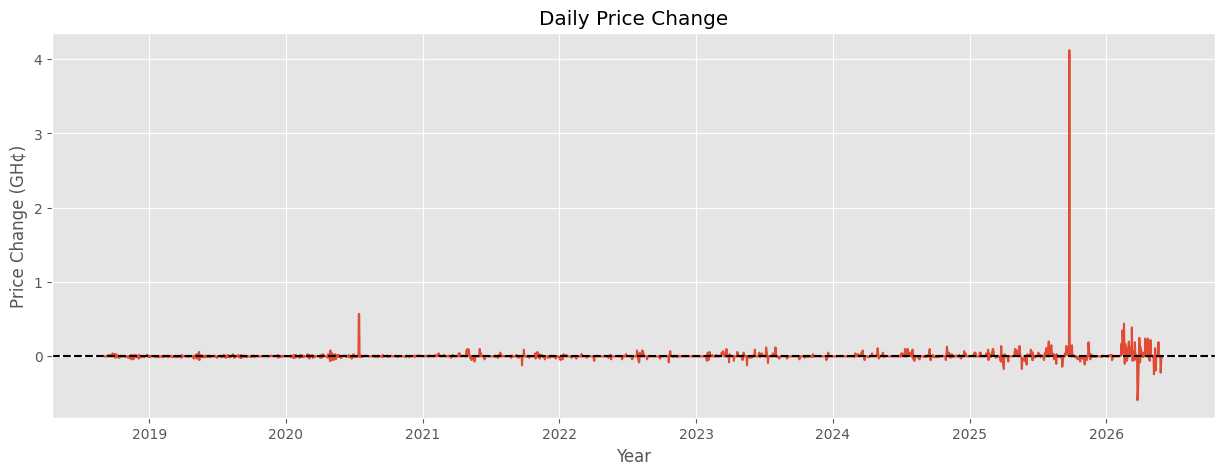

In [58]:
# ===========================================
# Daily Price Change
# ===========================================

plt.figure(figsize=(15,5))

plt.plot(
    df_clean["Daily Date"],
    df_clean["Price Change (GH¢)"]
)

plt.title("Daily Price Change")
plt.xlabel("Year")
plt.ylabel("Price Change (GH¢)")

plt.axhline(0, color="black", linestyle="--")

plt.show()

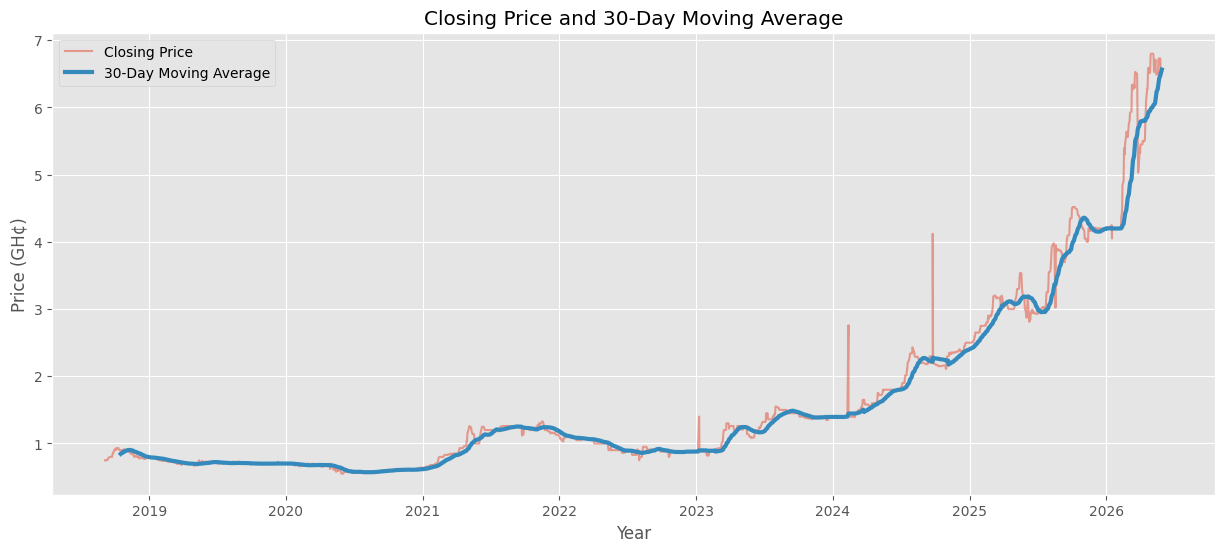

In [59]:
# ===========================================
# Moving Average
# ===========================================

df_clean["MA30"] = (
    df_clean["Closing Price - VWAP (GH¢)"]
    .rolling(30)
    .mean()
)

plt.figure(figsize=(15,6))

plt.plot(
    df_clean["Daily Date"],
    df_clean["Closing Price - VWAP (GH¢)"],
    alpha=0.5,
    label="Closing Price"
)

plt.plot(
    df_clean["Daily Date"],
    df_clean["MA30"],
    linewidth=3,
    label="30-Day Moving Average"
)

plt.title("Closing Price and 30-Day Moving Average")
plt.xlabel("Year")
plt.ylabel("Price (GH¢)")

plt.legend()

plt.show()

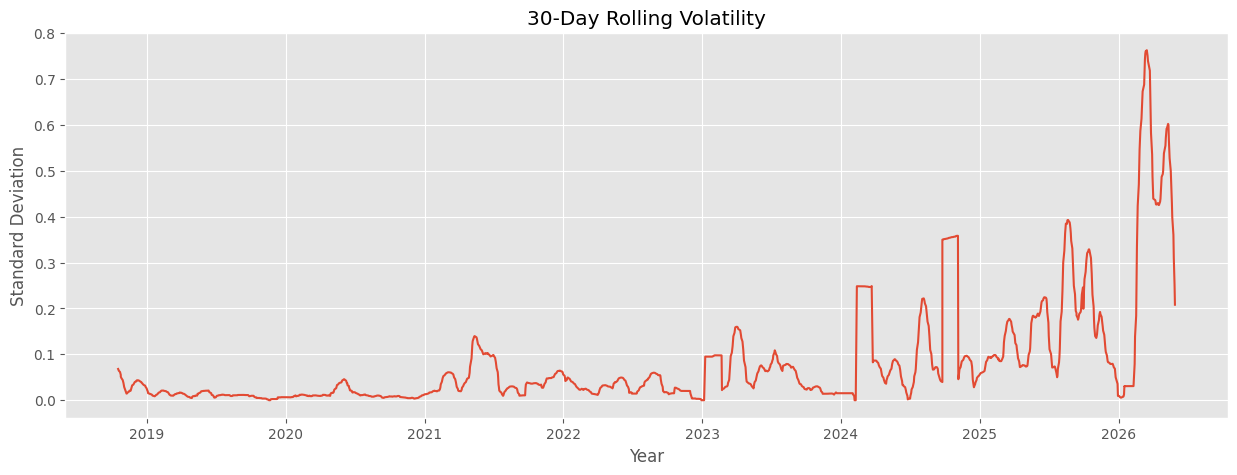

In [60]:
# ===========================================
# Rolling Volatility
# ===========================================

rolling_std = (
    df_clean["Closing Price - VWAP (GH¢)"]
    .rolling(30)
    .std()
)

plt.figure(figsize=(15,5))

plt.plot(
    df_clean["Daily Date"],
    rolling_std
)

plt.title("30-Day Rolling Volatility")
plt.xlabel("Year")
plt.ylabel("Standard Deviation")

plt.show()

# Stock Price Trend Analysis
## Closing Price Trend
Observation

The closing price remained relatively stable between 2018 and early 2021, fluctuating between approximately GH¢0.60 and GH¢1.00. From mid-2021, the stock experienced gradual growth, followed by a sharp upward trend beginning in 2024 and accelerating throughout 2025–2026, where the closing price reached approximately GH¢6.80. A few isolated price spikes are also observed, indicating periods of abnormal market activity.

## Interpretation

The overall trend indicates sustained long-term growth in MTN Ghana's stock price. The presence of non-linear trends and sudden price movements suggests that the underlying time series exhibits temporal dependencies and changing market dynamics. These characteristics justify the use of recurrent deep learning models such as LSTM and the proposed Attention-LSTM, which are designed to learn complex sequential patterns.

## Opening and Closing Prices
Observation

The opening and closing prices almost completely overlap throughout the observation period, indicating that daily opening prices closely follow daily closing prices. Only minor deviations occur during periods of increased market activity.

# Interpretation

The strong similarity between opening and closing prices suggests a high positive relationship between the two variables. Consequently, the opening price is expected to serve as an informative predictor of the closing price during model training.

## Daily Price Change
Observation

Most daily price changes are concentrated around zero, indicating relatively small day-to-day price fluctuations. However, a few significant positive and negative spikes occur, particularly during the later years of the dataset. One exceptionally large positive change is visible around late 2025.

## Interpretation

The stock generally experiences stable daily movements with occasional periods of high volatility. These abrupt changes may correspond to important market events or corporate announcements. Capturing such temporal fluctuations is essential for accurate forecasting, making sequential learning models particularly appropriate.

##  Closing Price and 30-Day Moving Average
Observation

The 30-day moving average closely follows the overall direction of the closing price while smoothing short-term fluctuations. During periods of rapid price increases, the moving average responds more gradually due to its smoothing effect.

## Interpretation

The moving average effectively highlights the long-term market trend while reducing short-term noise. This indicates that trend-based information exists within the dataset and supports the later inclusion of rolling statistical features during feature engineering.

## 30-Day Rolling Volatility
Observation

Market volatility remained relatively low between 2018 and 2022, followed by gradually increasing fluctuations beginning in 2023. The highest volatility occurs during 2025–2026, coinciding with the rapid increase in stock prices.

## Interpretation

The results indicate that market uncertainty increases during periods of rapid price appreciation. Since financial markets experience changing volatility over time, forecasting models must capture both stable and highly volatile market conditions. The ability of LSTM networks to model temporal dependencies, together with the Attention mechanism's capability to focus on influential historical observations, makes the proposed Attention-LSTM architecture suitable for this forecasting task.

## Overall Summary

The exploratory analysis reveals that MTN Ghana's stock prices exhibit a strong long-term upward trend, close alignment between opening and closing prices, generally stable daily price changes interrupted by occasional large movements, and increasing market volatility in recent years. The moving average confirms the presence of persistent long-term trends, while the rolling volatility demonstrates that market dynamics vary considerably over time. Collectively, these findings indicate that the dataset possesses clear temporal patterns and non-linear behaviour, supporting the use of sequence-based deep learning models. The observed trends also provide a strong basis for subsequent feature engineering, including lag variables, moving averages, rolling statistics, and technical indicators, which are expected to improve the predictive performance of the proposed Attention-LSTM model.

# 3.3 Trading Activity Analysis

This section investigates whether trading activity (volume and traded value) influences the movement of MTN Ghana's stock price. Trading activity often reflects investor interest and liquidity, making it an important component of financial forecasting

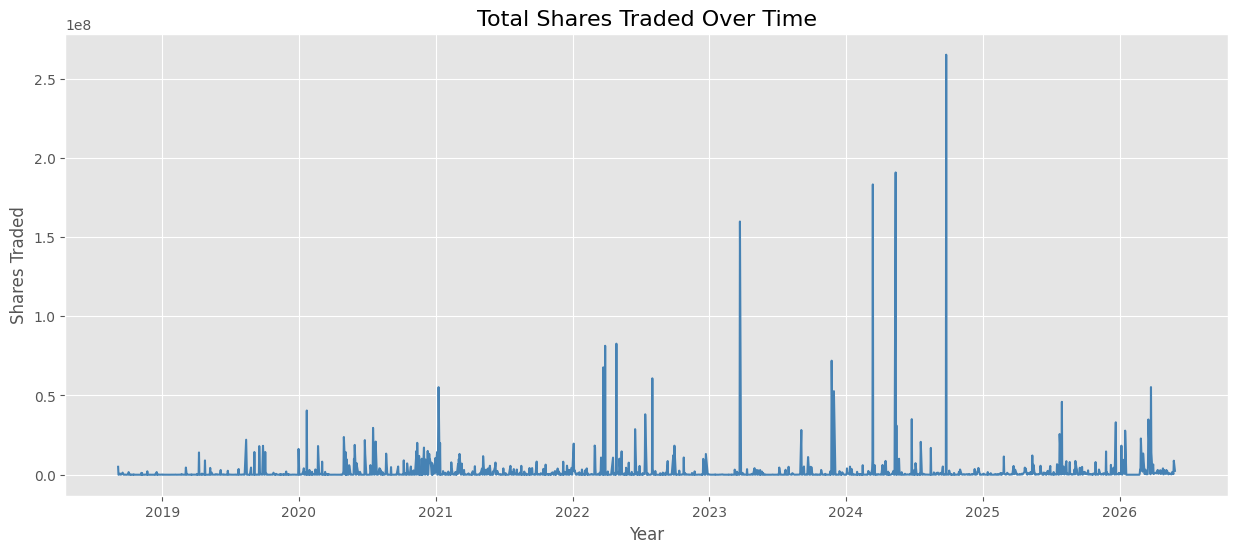

In [61]:
# ===========================================
# Total Shares Traded Over Time
# ===========================================

plt.figure(figsize=(15,6))

plt.plot(
    df_clean["Daily Date"],
    df_clean["Total Shares Traded"],
    color="steelblue"
)

plt.title("Total Shares Traded Over Time", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Shares Traded")

plt.grid(True)

plt.show()

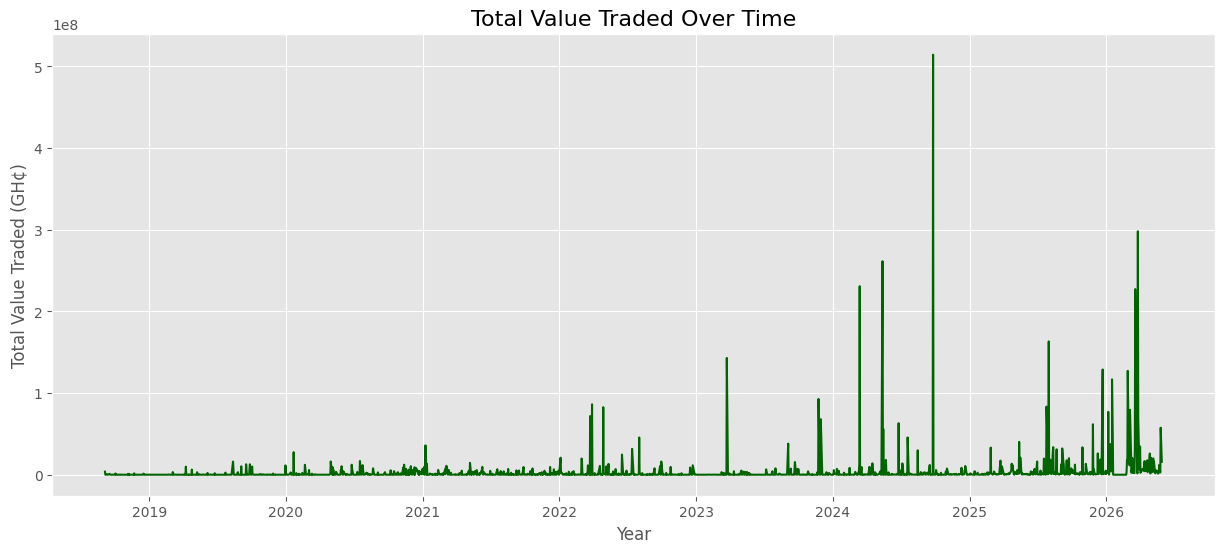

In [62]:
# ===========================================
# Total Value Traded Over Time
# ===========================================

plt.figure(figsize=(15,6))

plt.plot(
    df_clean["Daily Date"],
    df_clean["Total Value Traded (GH¢)"],
    color="darkgreen"
)

plt.title("Total Value Traded Over Time", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Total Value Traded (GH¢)")

plt.grid(True)

plt.show()

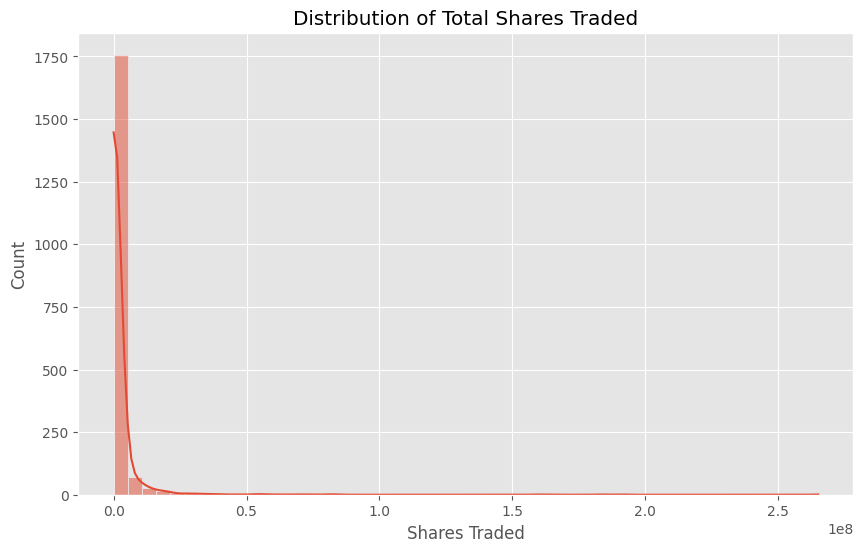

In [63]:
# ===========================================
# Distribution of Trading Volume
# ===========================================

plt.figure(figsize=(10,6))

sns.histplot(
    df_clean["Total Shares Traded"],
    bins=50,
    kde=True
)

plt.title("Distribution of Total Shares Traded")
plt.xlabel("Shares Traded")

plt.show()

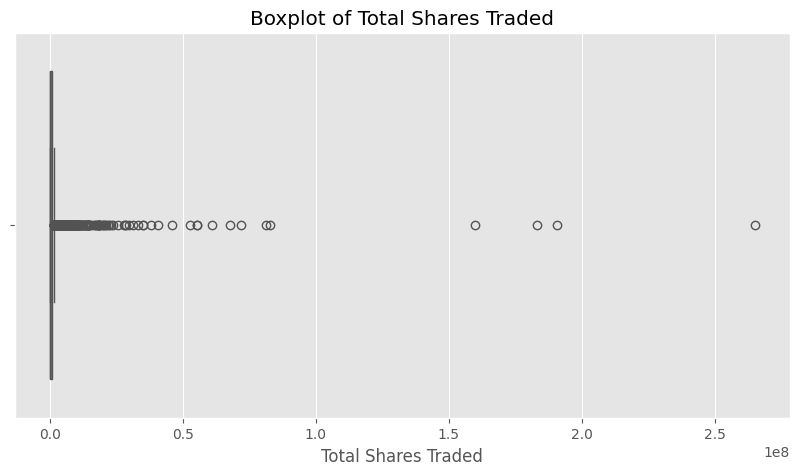

In [64]:
# ===========================================
# Trading Volume Boxplot
# ===========================================

plt.figure(figsize=(10,5))

sns.boxplot(
    x=df_clean["Total Shares Traded"]
)

plt.title("Boxplot of Total Shares Traded")

plt.show()

# 3.3 Trading Activity Analysis

## 3.3.1 Total Shares Traded Over Time

### Observation

The trading volume exhibits substantial fluctuations throughout the study period. While most trading days record relatively low trading volumes, several distinct spikes are observed, particularly from **2022 onwards**, with the highest trading activity occurring between **2024 and 2026**. These spikes indicate periods of exceptionally high investor participation.

### Interpretation

The irregular trading volume suggests that investor activity varies considerably over time and is likely influenced by market events, investor sentiment, or corporate announcements. The increasing frequency of large trading volumes during recent years coincides with the period of rapid stock price appreciation, indicating that trading volume may provide valuable predictive information for forecasting future stock prices.

---

## 3.3.2 Total Value Traded Over Time

### Observation

The total value traded follows a pattern similar to trading volume but exhibits even larger fluctuations in recent years. Several exceptionally high peaks are observed, with the largest occurring around **late 2024**, followed by additional spikes throughout **2025 and 2026**.

### Interpretation

Since total value traded combines both transaction volume and market price, the observed increase reflects the combined effect of higher stock prices and increased market participation. These findings suggest that total traded value captures important market dynamics and should be considered as a predictor during model development.

---

## 3.3.3 Distribution of Total Shares Traded

### Observation

The histogram reveals a highly **right-skewed** distribution. Most trading days are characterized by relatively low trading volumes, while only a small proportion of observations correspond to extremely large trading sessions.

### Interpretation

The positively skewed distribution indicates that unusually high trading volumes are infrequent but significant. This behaviour is typical of financial market data and suggests that scaling or logarithmic transformation may improve model stability during training.

---

## 3.3.4 Boxplot of Total Shares Traded

### Observation

The boxplot identifies numerous observations beyond the upper whisker, indicating the presence of several extreme trading volume values. These observations correspond to the volume spikes observed in the time-series plot.

### Interpretation

These extreme observations are likely genuine market events rather than data errors. Consequently, they should be retained during modelling because they represent meaningful periods of heightened market activity. Instead of removing these observations, appropriate feature scaling techniques will be applied to minimize their influence while preserving their informational value.

---

## Overall Summary

The trading activity analysis demonstrates that MTN Ghana's stock experiences highly variable investor participation, with substantial increases in both trading volume and traded value during recent years. Trading activity exhibits a positively skewed distribution with several extreme but meaningful observations corresponding to periods of heightened market interest. These findings suggest that trading volume and traded value contain valuable temporal information and should be retained as input features for the proposed Attention-LSTM model. Furthermore, the presence of skewed distributions supports the application of feature scaling during preprocessing to improve model convergence and predictive performance.

# 3.4 Distribution Analysis

This section investigates the statistical distribution of the numerical variables to understand their spread, skewness, and potential outliers. These insights will guide feature scaling and transformation before model development.

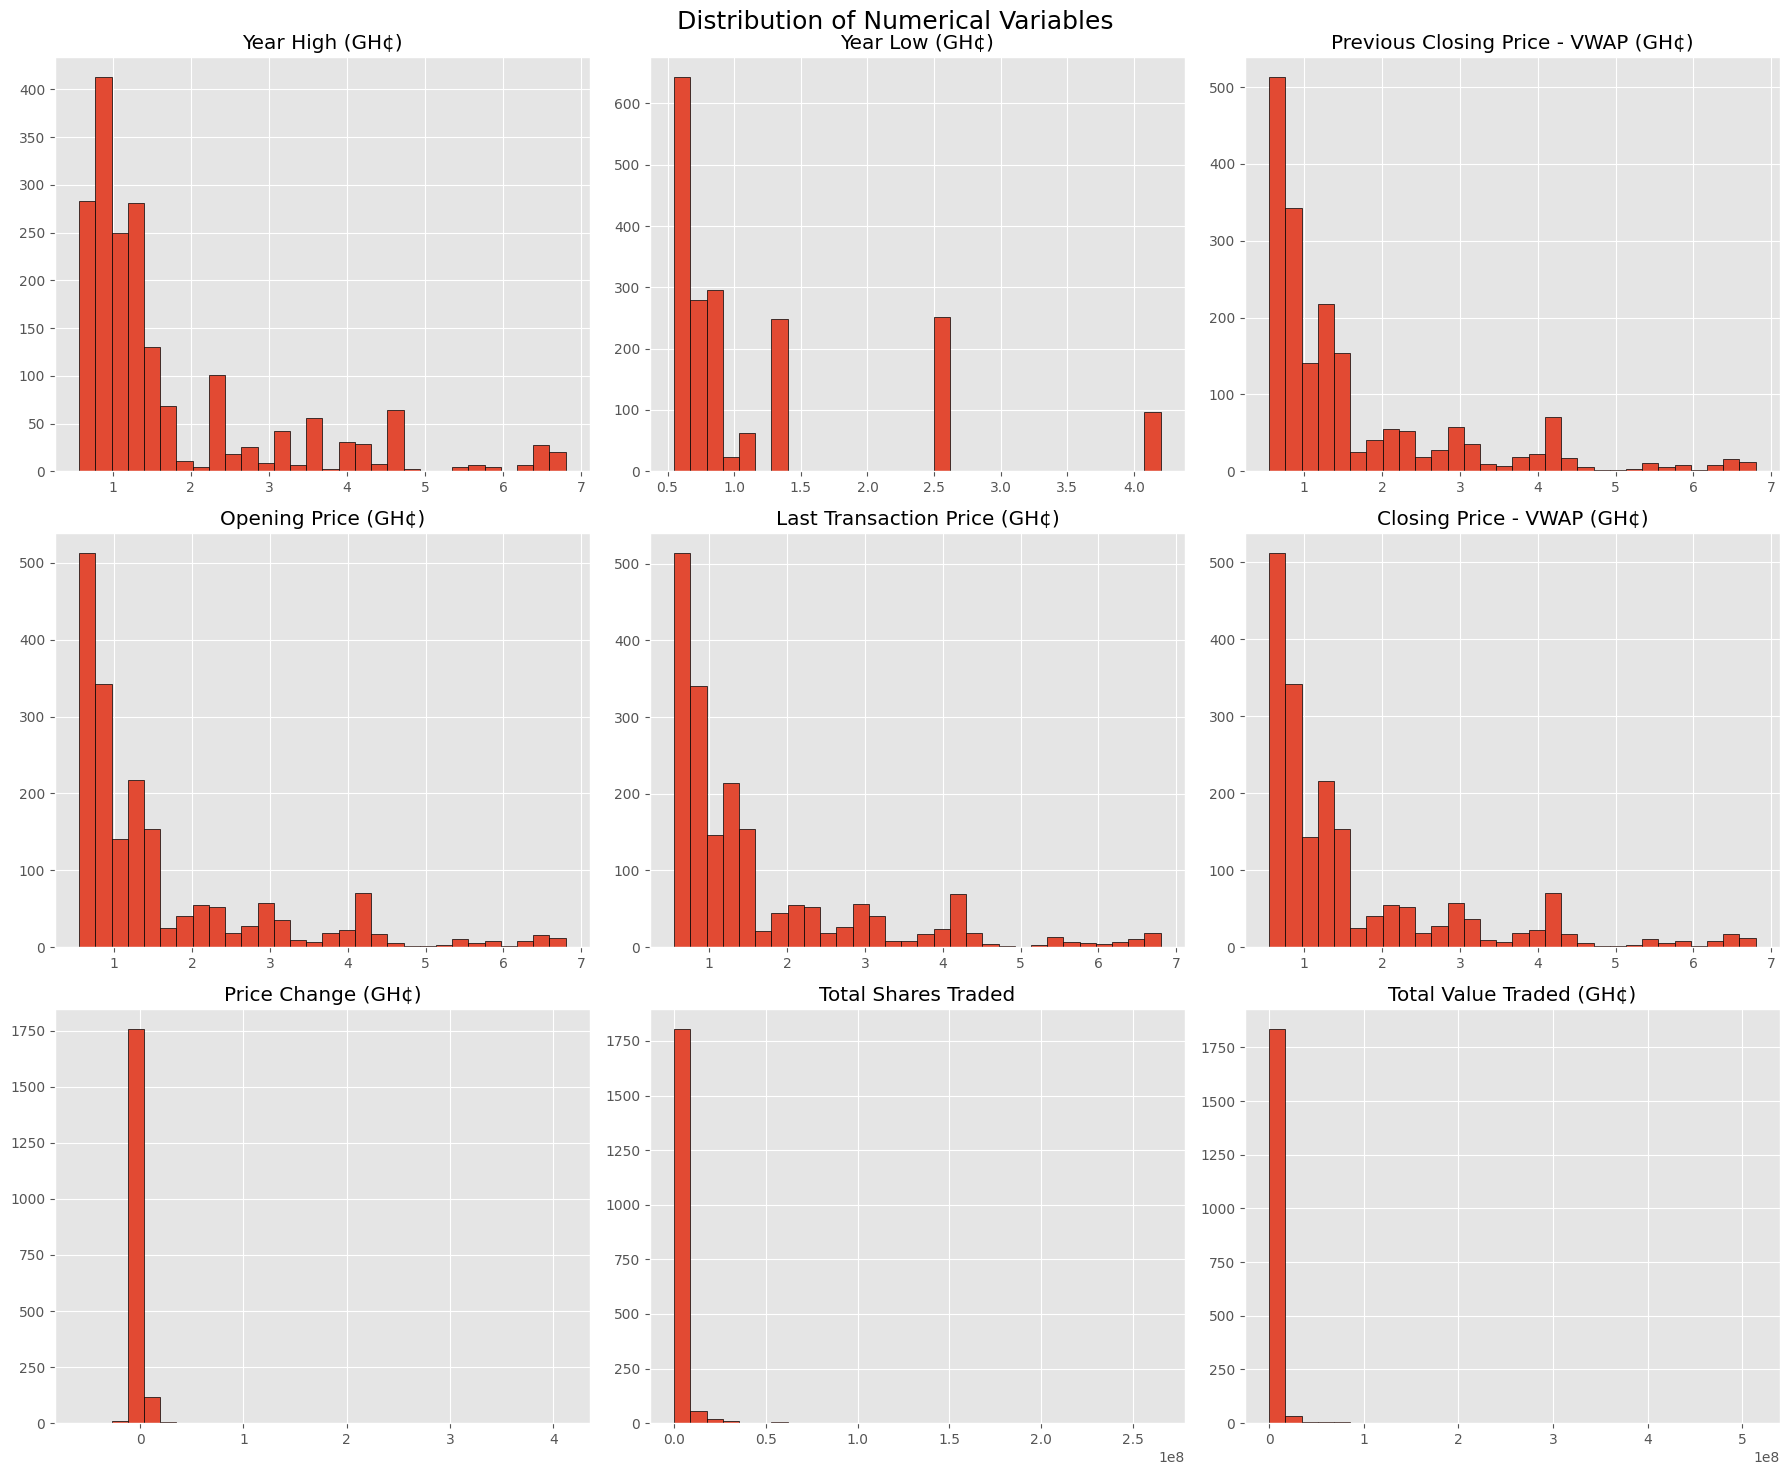

In [65]:
# ===========================================
# Distribution of Numerical Variables
# ===========================================

numeric_cols = [
    "Year High (GH¢)",
    "Year Low (GH¢)",
    "Previous Closing Price - VWAP (GH¢)",
    "Opening Price (GH¢)",
    "Last Transaction Price (GH¢)",
    "Closing Price - VWAP (GH¢)",
    "Price Change (GH¢)",
    "Total Shares Traded",
    "Total Value Traded (GH¢)"
]

df_clean[numeric_cols].hist(
    figsize=(18,15),
    bins=30,
    edgecolor='black'
)

plt.suptitle("Distribution of Numerical Variables", fontsize=18)
plt.tight_layout()
plt.show()

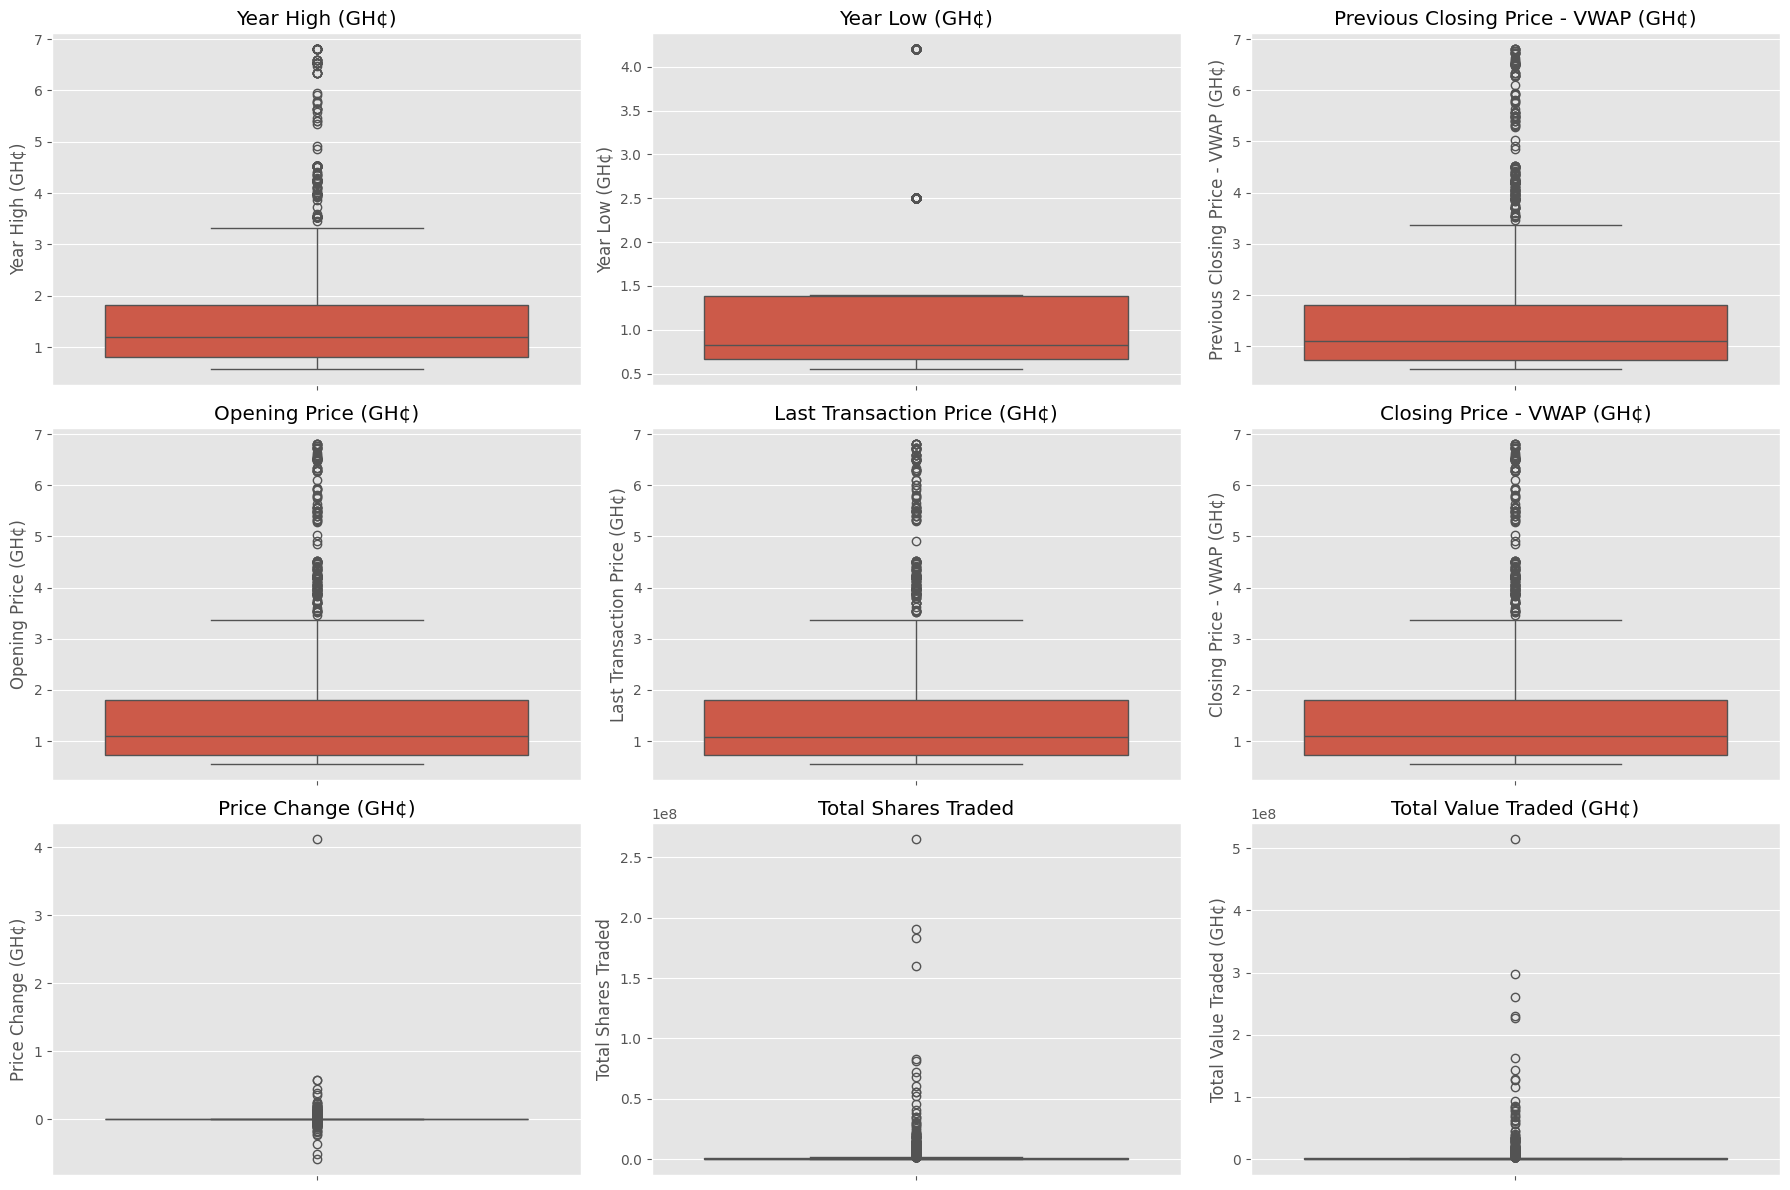

In [66]:
# ===========================================
# Boxplots of Numerical Variables
# ===========================================

fig, axes = plt.subplots(3, 3, figsize=(18, 12))

for ax, col in zip(axes.flatten(), numeric_cols):
    sns.boxplot(y=df_clean[col], ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [67]:
# ===========================================
# Skewness
# ===========================================

skewness = df_clean[numeric_cols].skew().sort_values(ascending=False)

print(skewness)

Price Change (GH¢)                     32.518168
Total Value Traded (GH¢)               15.547086
Total Shares Traded                    15.265256
Year Low (GH¢)                          1.930153
Last Transaction Price (GH¢)            1.914107
Year High (GH¢)                         1.910281
Previous Closing Price - VWAP (GH¢)     1.910271
Opening Price (GH¢)                     1.910258
Closing Price - VWAP (GH¢)              1.909720
dtype: float64


In [68]:
# ===========================================
# Kurtosis
# ===========================================

kurtosis = df_clean[numeric_cols].kurtosis().sort_values(ascending=False)

print(kurtosis)

Price Change (GH¢)                     1281.323999
Total Value Traded (GH¢)                319.965027
Total Shares Traded                     292.203581
Last Transaction Price (GH¢)              3.302517
Opening Price (GH¢)                       3.294414
Previous Closing Price - VWAP (GH¢)       3.294365
Closing Price - VWAP (GH¢)                3.284996
Year High (GH¢)                           3.217028
Year Low (GH¢)                            3.066113
dtype: float64


In [69]:
# ===========================================
# Distribution Summary
# ===========================================

distribution_summary = pd.DataFrame({
    "Mean": df_clean[numeric_cols].mean(),
    "Median": df_clean[numeric_cols].median(),
    "Std Dev": df_clean[numeric_cols].std(),
    "Skewness": df_clean[numeric_cols].skew(),
    "Kurtosis": df_clean[numeric_cols].kurtosis()
})

distribution_summary.round(3)

,Mean,Median,Std Dev,Skewness,Kurtosis
Year High (GH¢),1.729,1.20,1.372000e+00,1.910,3.217
Year Low (GH¢),1.225,0.82,9.240000e-01,1.930,3.066
Previous Closing Price - VWAP (GH¢),1.617,1.10,1.319000e+00,1.910,3.294
Opening Price (GH¢),1.617,1.10,1.319000e+00,1.910,3.294
Last Transaction Price (GH¢),1.622,1.09,1.327000e+00,1.914,3.303
Closing Price - VWAP (GH¢),1.620,1.10,1.324000e+00,1.910,3.285
Price Change (GH¢),0.006,0.00,1.040000e-01,32.518,1281.324
Total Shares Traded,2013476.786,61858.00,1.091555e+07,15.265,292.204
Total Value Traded (GH¢),3412400.228,68788.30,1.944361e+07,15.547,319.965


# 3.4 Distribution Analysis

## Observation

The histograms reveal that nearly all numerical variables exhibit **positively skewed distributions**. The price-related variables, including **Year High**, **Year Low**, **Previous Closing Price**, **Opening Price**, **Last Transaction Price**, and **Closing Price**, are concentrated at lower price levels with long right tails. This distribution reflects the gradual appreciation of MTN Ghana's stock price over the study period.

The **Price Change** variable is centred around zero, indicating that most daily price movements are relatively small. However, a few extreme positive and negative observations are present, representing periods of unusually high market volatility.

The **Total Shares Traded** and **Total Value Traded** variables display extremely right-skewed distributions, where the majority of trading days recorded relatively low trading activity, while a small number of days experienced exceptionally large trading volumes and transaction values.

The boxplots further confirm the presence of numerous observations beyond the upper whiskers across almost all numerical variables. These outliers are particularly pronounced for **Total Shares Traded**, **Total Value Traded**, and **Price Change**. Rather than indicating data quality issues, these observations correspond to genuine periods of unusually high trading activity and significant market movements.

The distribution summary statistics reinforce these findings. Most price-related variables have moderate positive skewness (approximately **1.9**) and kurtosis values around **3**, indicating moderately heavy-tailed distributions. In contrast, **Price Change**, **Total Shares Traded**, and **Total Value Traded** exhibit extremely high skewness and kurtosis values, demonstrating the presence of infrequent but exceptionally large market events.

---

## Interpretation

The observed distributional characteristics are consistent with those commonly found in financial time-series data. The moderate positive skewness of the price variables reflects the sustained long-term appreciation of MTN Ghana's stock price throughout the study period. Meanwhile, the extreme skewness observed in trading volume, traded value, and daily price changes indicates that financial markets occasionally experience unusually high trading activity and abrupt price movements.

These findings suggest that the dataset does not follow a normal distribution, which is expected for stock market data. Consequently, feature scaling will be required before model training to ensure that variables measured on different scales contribute appropriately during optimization. The identified outliers represent meaningful market events rather than data errors and will therefore be retained to preserve valuable information that may improve the predictive capability of the proposed Attention-LSTM model.

Furthermore, the heavy-tailed nature of the trading variables highlights the importance of using deep learning models capable of learning complex, nonlinear temporal relationships. The Attention-LSTM architecture is well suited for this task because it can selectively focus on influential historical observations, including periods of heightened market activity, while modelling long-term sequential dependencies.

# 3.5 Correlation Analysis

This is one of the most important sections because it tells us which variables have the strongest linear relationship with the target variable (Closing Price - VWAP) and provides evidence for feature selection.

In [71]:
# ===========================================
# Correlation Matrix
# ===========================================

numeric_df = df_clean.select_dtypes(include=["number"])

corr_matrix = numeric_df.corr()

corr_matrix.round(3)

,Year High (GH¢),Year Low (GH¢),Previous Closing Price - VWAP (GH¢),Opening Price (GH¢),Last Transaction Price (GH¢),Closing Price - VWAP (GH¢),Price Change (GH¢),Total Shares Traded,Total Value Traded (GH¢),MA30
Year High (GH¢),1.000,0.952,0.995,0.995,0.995,0.995,0.074,0.024,0.183,0.995
Year Low (GH¢),0.952,1.000,0.955,0.955,0.956,0.955,0.074,0.025,0.177,0.953
Previous Closing Price - VWAP (GH¢),0.995,0.955,1.000,1.000,0.999,1.000,0.074,0.023,0.182,0.993
Opening Price (GH¢),0.995,0.955,1.000,1.000,0.999,1.000,0.074,0.023,0.182,0.993
Last Transaction Price (GH¢),0.995,0.956,0.999,0.999,1.000,1.000,0.086,0.022,0.179,0.992
Closing Price - VWAP (GH¢),0.995,0.955,1.000,1.000,1.000,1.000,0.086,0.022,0.179,0.992
Price Change (GH¢),0.074,0.074,0.074,0.074,0.086,0.086,1.000,-0.018,-0.037,0.072
Total Shares Traded,0.024,0.025,0.023,0.023,0.022,0.022,-0.018,1.000,0.868,0.020
Total Value Traded (GH¢),0.183,0.177,0.182,0.182,0.179,0.179,-0.037,0.868,1.000,0.176
MA30,0.995,0.953,0.993,0.993,0.992,0.992,0.072,0.020,0.176,1.000


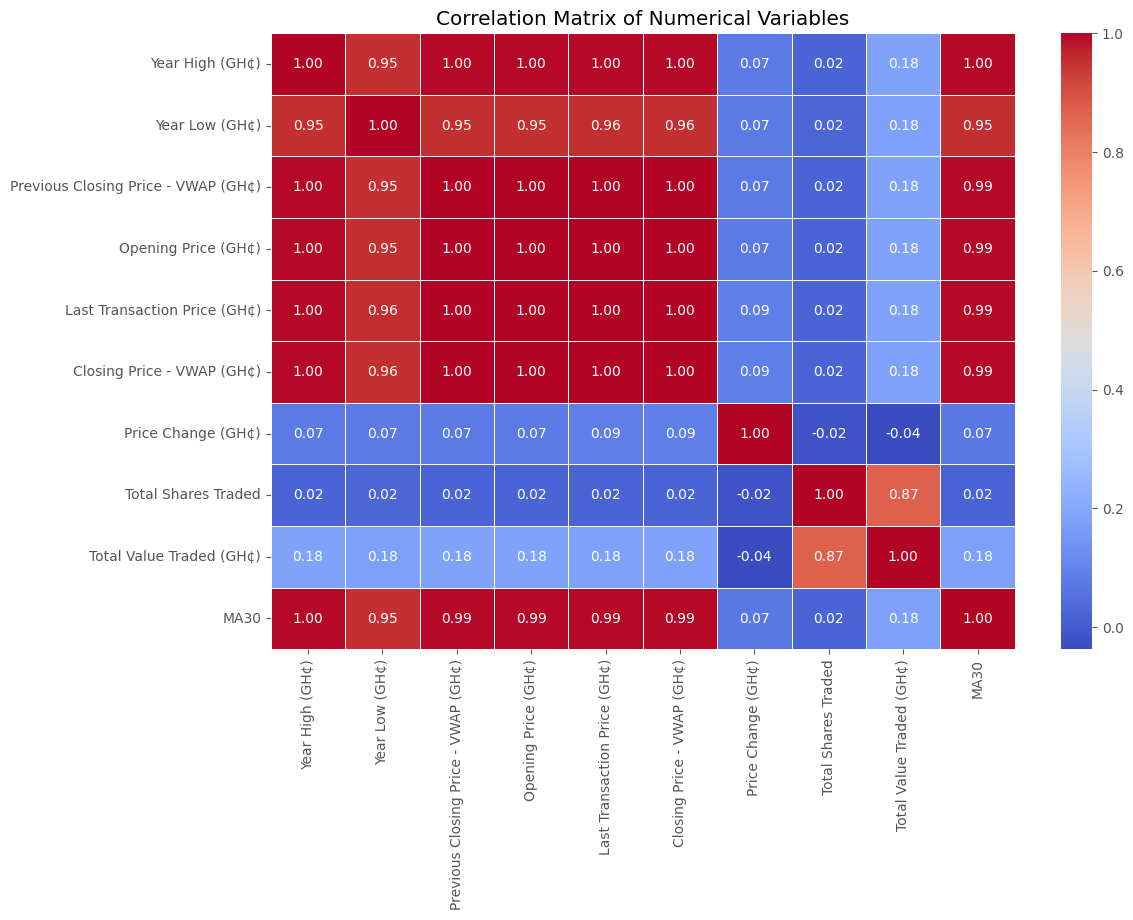

In [72]:
# ===========================================
# Correlation Heatmap
# ===========================================

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Variables")

plt.show()

In [73]:
# ===========================================
# Correlation with Target
# ===========================================

target_corr = (
    corr_matrix["Closing Price - VWAP (GH¢)"]
    .sort_values(ascending=False)
)

target_corr

,Closing Price - VWAP (GH¢)
Closing Price - VWAP (GH¢),1.000000
Last Transaction Price (GH¢),0.999866
Previous Closing Price - VWAP (GH¢),0.999546
Opening Price (GH¢),0.999546
Year High (GH¢),0.995101
MA30,0.992403
Year Low (GH¢),0.955156
Total Value Traded (GH¢),0.178867
Price Change (GH¢),0.085514
Total Shares Traded,0.022041


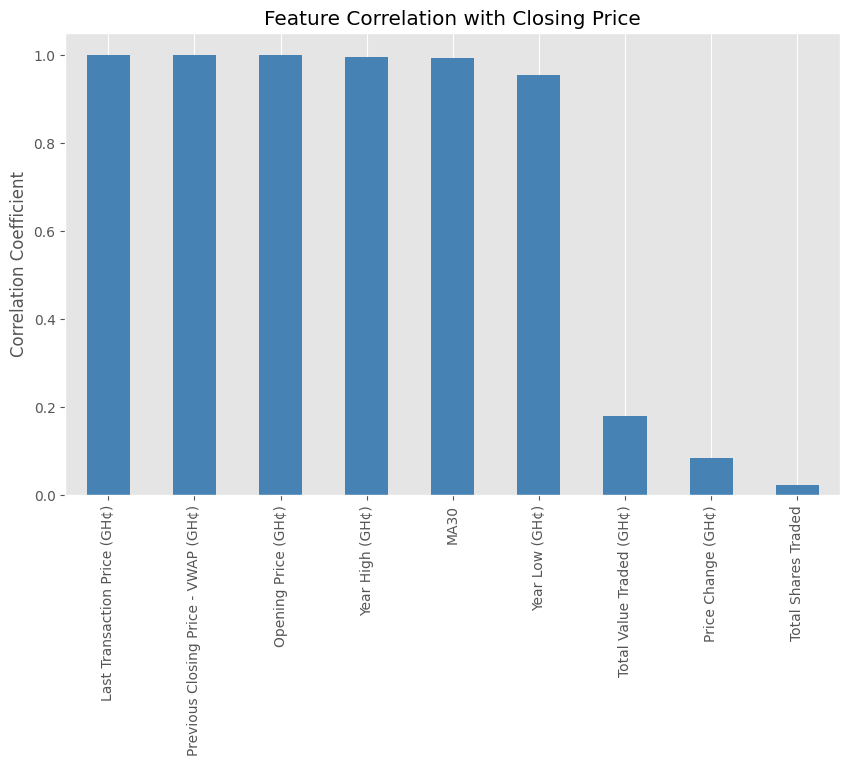

In [74]:
# ===========================================
# Correlation with Target Variable
# ===========================================

plt.figure(figsize=(10,6))

target_corr.drop("Closing Price - VWAP (GH¢)").plot(
    kind="bar",
    color="steelblue"
)

plt.ylabel("Correlation Coefficient")
plt.title("Feature Correlation with Closing Price")

plt.grid(axis="y")

plt.show()

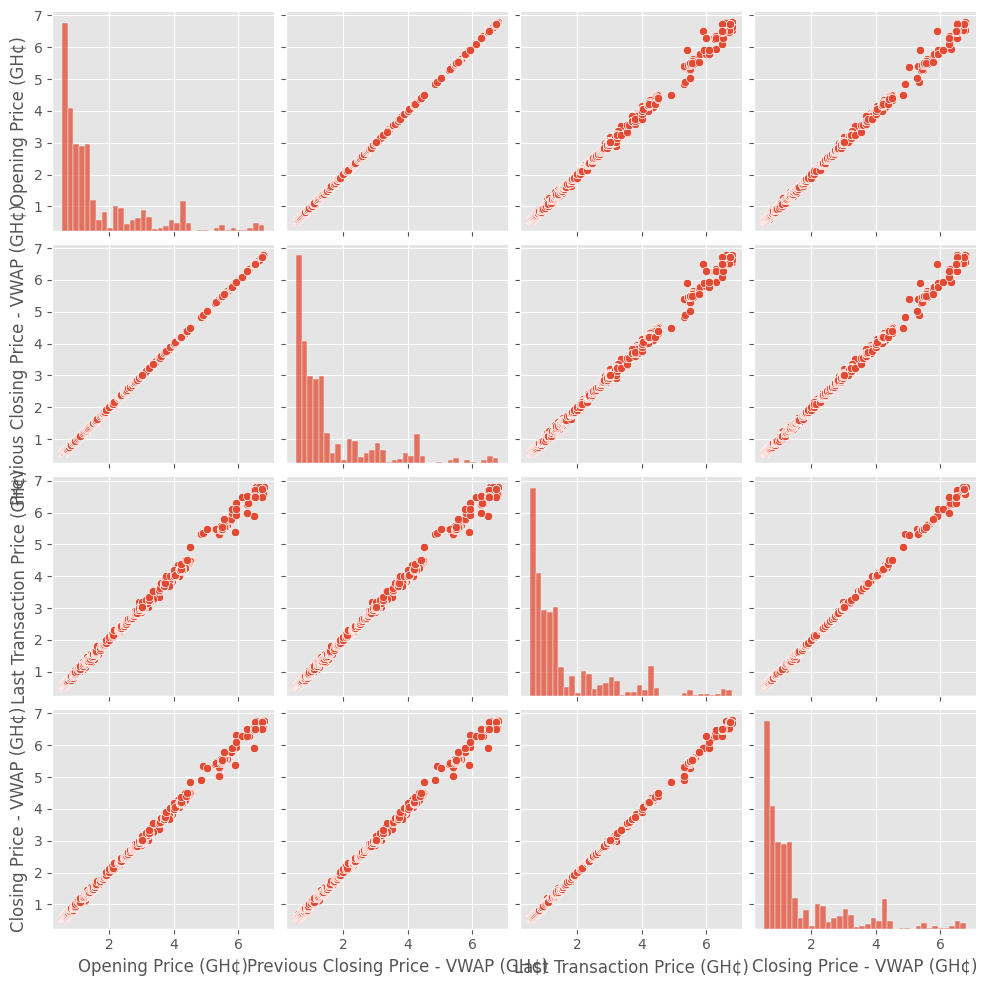

In [75]:
# ===========================================
# Pairplot
# ===========================================

important_cols = [
    "Opening Price (GH¢)",
    "Previous Closing Price - VWAP (GH¢)",
    "Last Transaction Price (GH¢)",
    "Closing Price - VWAP (GH¢)"
]

sns.pairplot(df_clean[important_cols])

plt.show()

# 3.5 Correlation Analysis

## Observation

The correlation matrix reveals very strong positive relationships among the stock price variables. The **Closing Price** exhibits an almost perfect positive correlation with the **Last Transaction Price** (0.9999), **Previous Closing Price** (0.9995), and **Opening Price** (0.9995). Similarly, **Year High** (0.9951), **Year Low** (0.9552), and the **30-Day Moving Average (MA30)** (0.9924) also show strong positive correlations with the closing price.

In contrast, the trading activity variables exhibit considerably weaker linear relationships with the target variable. **Total Value Traded** has a relatively weak positive correlation (0.1789), while **Total Shares Traded** has an almost negligible correlation (0.0220). Likewise, **Price Change** demonstrates only a weak positive correlation (0.0855) with the closing price.

The pairwise scatter plots reinforce these findings. The relationships between the opening price, previous closing price, last transaction price, and closing price are almost perfectly linear, with observations closely aligned along the diagonal. This indicates a strong linear dependency among these market price variables.

---

## Interpretation

The correlation analysis demonstrates that historical price variables are the strongest predictors of the closing price. In particular, the **Last Transaction Price**, **Opening Price**, **Previous Closing Price**, and **30-Day Moving Average** provide substantial predictive information due to their extremely high correlations with the target variable.

Although **Total Shares Traded** and **Total Value Traded** exhibit relatively weak linear correlations, they should not be excluded solely on this basis. Correlation analysis measures only linear relationships, whereas financial markets frequently exhibit nonlinear interactions between trading activity and price movements. Since the proposed Attention-LSTM model is capable of learning complex nonlinear temporal patterns, these variables may still contribute useful predictive information when combined with other market features.

The extremely high correlations observed among several price variables also indicate the presence of multicollinearity. While multicollinearity can negatively affect traditional regression models, it is generally less problematic for deep learning architectures. Nevertheless, the feature engineering stage will focus on constructing informative temporal features, such as lag variables and rolling statistics, rather than relying exclusively on highly correlated raw price variables.

Overall, the correlation analysis confirms that the dataset contains strong predictive signals for stock price forecasting and supports the development of a multivariate Attention-LSTM model that integrates historical prices, trading activity, and engineered temporal features.

# 3.6 Time-Based Pattern Analysis

In [77]:
# ===========================================
# Create Time-Based Features
# ===========================================

df_clean["Year"] = df_clean["Daily Date"].dt.year
df_clean["Month"] = df_clean["Daily Date"].dt.month
df_clean["Month_Name"] = df_clean["Daily Date"].dt.month_name()
df_clean["Quarter"] = df_clean["Daily Date"].dt.quarter
df_clean["Day_of_Week"] = df_clean["Daily Date"].dt.day_name()

df_clean[["Daily Date","Year","Month","Quarter","Day_of_Week"]].head()

,Daily Date,Year,Month,Quarter,Day_of_Week
0,2018-09-05,2018,9,3,Wednesday
1,2018-09-06,2018,9,3,Thursday
2,2018-09-07,2018,9,3,Friday
3,2018-09-10,2018,9,3,Monday
4,2018-09-11,2018,9,3,Tuesday


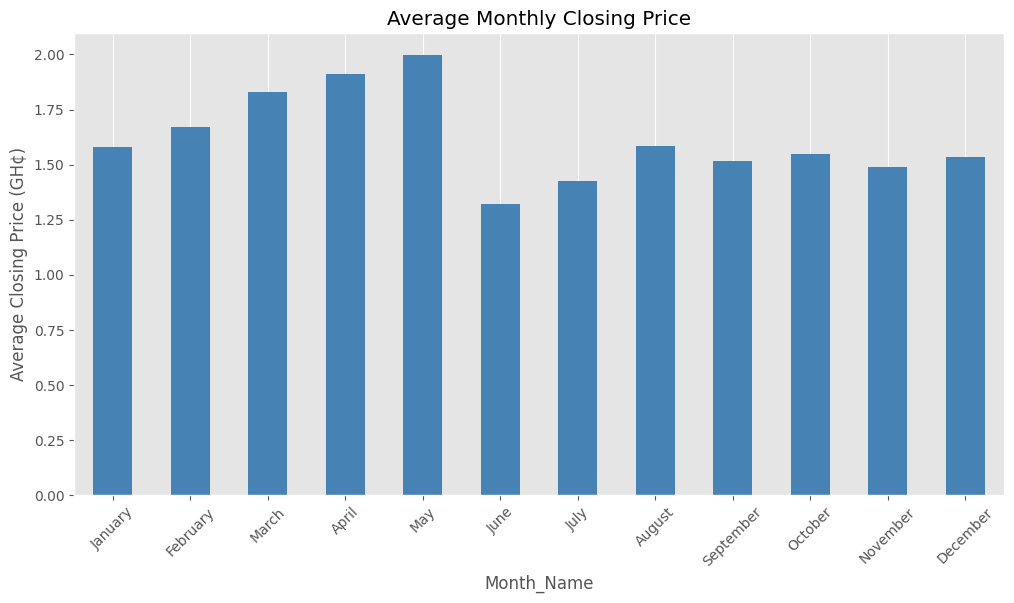

In [78]:
# ===========================================
# Average Monthly Closing Price
# ===========================================

monthly_price = (
    df_clean.groupby("Month_Name")["Closing Price - VWAP (GH¢)"]
    .mean()
    .reindex([
        "January","February","March","April",
        "May","June","July","August",
        "September","October","November","December"
    ])
)

plt.figure(figsize=(12,6))

monthly_price.plot(
    kind="bar",
    color="steelblue"
)

plt.ylabel("Average Closing Price (GH¢)")
plt.title("Average Monthly Closing Price")

plt.xticks(rotation=45)

plt.grid(axis="y")

plt.show()

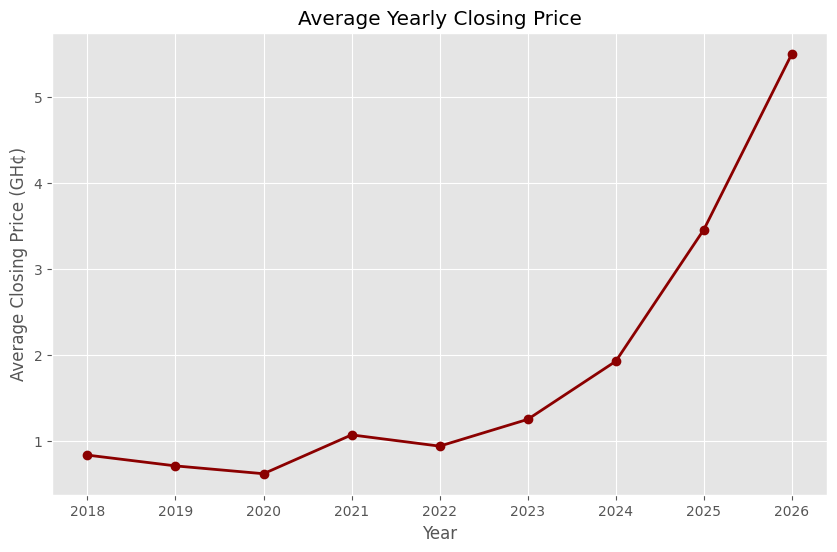

In [79]:
# ===========================================
# Average Closing Price by Year
# ===========================================

yearly_price = (
    df_clean.groupby("Year")["Closing Price - VWAP (GH¢)"]
    .mean()
)

plt.figure(figsize=(10,6))

yearly_price.plot(
    marker="o",
    linewidth=2,
    color="darkred"
)

plt.ylabel("Average Closing Price (GH¢)")
plt.title("Average Yearly Closing Price")

plt.grid(True)

plt.show()

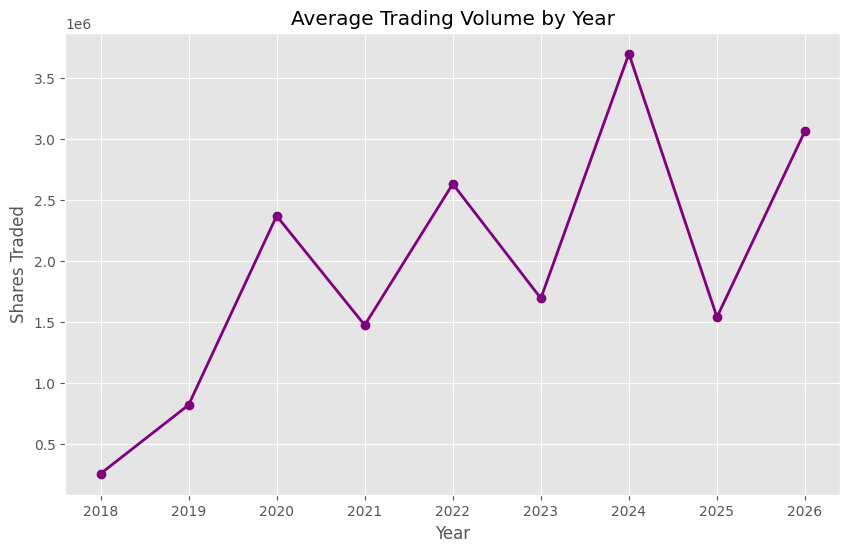

In [80]:
# ===========================================
# Average Trading Volume by Year
# ===========================================

yearly_volume = (
    df_clean.groupby("Year")["Total Shares Traded"]
    .mean()
)

plt.figure(figsize=(10,6))

yearly_volume.plot(
    marker="o",
    linewidth=2,
    color="purple"
)

plt.title("Average Trading Volume by Year")

plt.ylabel("Shares Traded")

plt.grid(True)

plt.show()

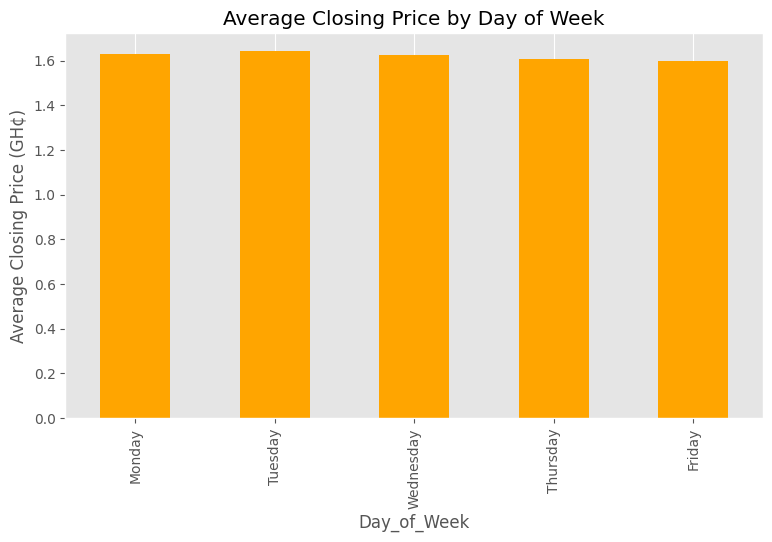

In [81]:
# ===========================================
# Average Closing Price by Day of Week
# ===========================================

weekday_price = (
    df_clean.groupby("Day_of_Week")["Closing Price - VWAP (GH¢)"]
    .mean()
    .reindex([
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday"
    ])
)

plt.figure(figsize=(9,5))

weekday_price.plot(
    kind="bar",
    color="orange"
)

plt.ylabel("Average Closing Price (GH¢)")
plt.title("Average Closing Price by Day of Week")

plt.grid(axis="y")

plt.show()

# 3.6 Time-Based Pattern Analysis

## Observation

The time-based analysis reveals several temporal patterns in MTN Ghana's stock price and trading activity.

The **average monthly closing price** varies across the calendar year. Closing prices generally increase from **January to May**, with **May** recording the highest average closing price of approximately **GH¢2.00**. A noticeable decline occurs in **June**, after which prices remain relatively stable for the remainder of the year. This pattern suggests the presence of seasonal variations in stock performance.

The **yearly trend** demonstrates a clear long-term increase in the average closing price. Following relatively stable prices between **2018 and 2023**, the stock experienced rapid appreciation during **2024**, with substantial increases continuing through **2025** and **2026**. This confirms the strong upward trend previously observed in the time-series analysis.

The **average trading volume by year** exhibits considerable variation over the study period. Trading activity increased substantially after 2019, reaching its highest average level in **2024**, before declining in **2025** and rising again in **2026**. These fluctuations indicate changing levels of investor participation across different years.

The **day-of-week analysis** shows only minor differences in average closing prices across the five trading days. Tuesday records a slightly higher average closing price, while Friday records the lowest. However, the differences are relatively small, suggesting the absence of strong weekly calendar effects.

---

## Interpretation

The yearly analysis confirms that MTN Ghana's stock exhibits a strong long-term upward trend, indicating that historical information plays a critical role in predicting future prices. This finding further supports the application of sequence-based deep learning models such as LSTM and Attention-LSTM, which are designed to capture temporal dependencies in sequential financial data.

The variation observed across months suggests that seasonal market behaviour may influence stock prices. Consequently, calendar-based variables such as **Month**, **Quarter**, and **Year** may provide useful contextual information during model training.

The fluctuations in yearly trading volume indicate that investor participation changes over time and may contribute additional predictive information when combined with historical price data.

Conversely, the minimal differences observed across weekdays suggest that the day of the week has only a limited influence on MTN Ghana's closing price. Although this feature will be retained for further experimentation, it is expected to contribute less to the forecasting model than historical price and trading variables.

Overall, the time-based analysis demonstrates that long-term temporal trends and seasonal effects exist within the dataset. These findings justify the inclusion of calendar-related features during feature engineering and further support the development of a multivariate Attention-LSTM model capable of learning complex temporal relationships.

# Phase 4: Feature Engineering
Objective

The objective of feature engineering is to transform the cleaned stock market data into more informative variables that capture temporal dependencies, price momentum, volatility, market trends, and calendar effects. These engineered features enrich the information available to the forecasting model and improve its ability to learn complex nonlinear relationships in financial time-series data.

In [82]:
# ===========================================
# 4.1 Lag Features
# ===========================================

# Closing Price Lags
df_clean["Close_Lag1"] = df_clean["Closing Price - VWAP (GH¢)"].shift(1)
df_clean["Close_Lag3"] = df_clean["Closing Price - VWAP (GH¢)"].shift(3)
df_clean["Close_Lag5"] = df_clean["Closing Price - VWAP (GH¢)"].shift(5)
df_clean["Close_Lag7"] = df_clean["Closing Price - VWAP (GH¢)"].shift(7)

# Opening Price Lags
df_clean["Open_Lag1"] = df_clean["Opening Price (GH¢)"].shift(1)
df_clean["Open_Lag3"] = df_clean["Opening Price (GH¢)"].shift(3)

# Trading Volume Lags
df_clean["Volume_Lag1"] = df_clean["Total Shares Traded"].shift(1)
df_clean["Volume_Lag3"] = df_clean["Total Shares Traded"].shift(3)

# Traded Value Lags
df_clean["Value_Lag1"] = df_clean["Total Value Traded (GH¢)"].shift(1)
df_clean["Value_Lag3"] = df_clean["Total Value Traded (GH¢)"].shift(3)

# Display first rows
df_clean.head(10)

,Daily Date,Share Code,Year High (GH¢),Year Low (GH¢),Previous Closing Price - VWAP (GH¢),Opening Price (GH¢),Last Transaction Price (GH¢),Closing Price - VWAP (GH¢),Price Change (GH¢),Total Shares Traded,Total Value Traded (GH¢),MA30,Year,Month,Month_Name,Quarter,Day_of_Week,Close_Lag1,Close_Lag3,Close_Lag5,Close_Lag7,Open_Lag1,Open_Lag3,Volume_Lag1,Volume_Lag3,Value_Lag1,Value_Lag3
0,2018-09-05,MTNGH,0.75,0.75,0.75,0.75,0.75,0.75,0.00,5007600.0,3755700.0,NaN,2018,9,September,3,Wednesday,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2018-09-06,MTNGH,0.75,0.75,0.75,0.75,0.75,0.75,0.00,0.0,0.0,NaN,2018,9,September,3,Thursday,0.75,NaN,NaN,NaN,0.75,NaN,5007600.0,NaN,3755700.0,NaN
2,2018-09-07,MTNGH,0.75,0.75,0.75,0.75,0.75,0.75,0.00,0.0,0.0,NaN,2018,9,September,3,Friday,0.75,NaN,NaN,NaN,0.75,NaN,0.0,NaN,0.0,NaN
3,2018-09-10,MTNGH,0.75,0.75,0.75,0.75,0.75,0.75,0.00,720000.0,540000.0,NaN,2018,9,September,3,Monday,0.75,0.75,NaN,NaN,0.75,0.75,0.0,5007600.0,0.0,3755700.0
4,2018-09-11,MTNGH,0.76,0.75,0.75,0.75,0.77,0.76,0.01,565900.0,430084.0,NaN,2018,9,September,3,Tuesday,0.75,0.75,NaN,NaN,0.75,0.75,720000.0,0.0,540000.0,0.0
5,2018-09-12,MTNGH,0.76,0.75,0.76,0.76,0.77,0.76,0.00,3000.0,2280.0,NaN,2018,9,September,3,Wednesday,0.76,0.75,0.75,NaN,0.75,0.75,565900.0,0.0,430084.0,0.0
6,2018-09-13,MTNGH,0.77,0.75,0.76,0.76,0.77,0.77,0.01,156800.0,120736.0,NaN,2018,9,September,3,Thursday,0.76,0.75,0.75,NaN,0.76,0.75,3000.0,720000.0,2280.0,540000.0
7,2018-09-14,MTNGH,0.78,0.75,0.77,0.77,0.78,0.78,0.01,266000.0,207480.0,NaN,2018,9,September,3,Friday,0.77,0.76,0.75,0.75,0.76,0.75,156800.0,565900.0,120736.0,430084.0
8,2018-09-17,MTNGH,0.80,0.75,0.78,0.78,0.80,0.80,0.02,1311900.0,1049520.0,NaN,2018,9,September,3,Monday,0.78,0.76,0.75,0.75,0.77,0.76,266000.0,3000.0,207480.0,2280.0
9,2018-09-18,MTNGH,0.80,0.75,0.80,0.80,0.80,0.80,0.00,861900.0,689520.0,NaN,2018,9,September,3,Tuesday,0.80,0.77,0.76,0.75,0.78,0.76,1311900.0,156800.0,1049520.0,120736.0


In [83]:
# Missing values introduced by lag features

lag_columns = [col for col in df_clean.columns if "Lag" in col]

df_clean[lag_columns].isnull().sum()

,0
Close_Lag1,1
Close_Lag3,3
Close_Lag5,5
Close_Lag7,7
Open_Lag1,1
Open_Lag3,3
Volume_Lag1,1
Volume_Lag3,3
Value_Lag1,1
Value_Lag3,3


# 4.1 Lag Features

## Observation

Lag features were generated to capture historical information from previous trading periods. Specifically, lagged values were created for the closing price, opening price, trading volume, and traded value using one-day, three-day, five-day, and seven-day delays where appropriate.

As expected, the lagging operation introduced missing values at the beginning of the dataset because historical observations are unavailable for the earliest trading days.

---

## Interpretation

Lag features enable the forecasting model to explicitly incorporate historical market information when predicting future stock prices. Since financial markets exhibit strong temporal dependence, previous prices and trading activity often provide valuable signals regarding future market behaviour.

The selected lag intervals capture both short-term market dynamics (1- and 3-day lags) and slightly longer temporal dependencies (5- and 7-day lags). These engineered variables are expected to improve the predictive capability of the proposed Attention-LSTM model by providing richer sequential information during training.

The missing values introduced through lagging are a natural consequence of the feature engineering process and will be removed after all engineered features have been created.

4.2 Rolling Statistical Features
Objective

Rolling statistics summarize recent market behaviour over a fixed window rather than relying on a single observation. They help the model distinguish between temporary price fluctuations and underlying market trends.

In [84]:
# ===========================================
# 4.2 Rolling Means
# ===========================================

df_clean["MA7"] = (
    df_clean["Closing Price - VWAP (GH¢)"]
    .rolling(window=7)
    .mean()
)

df_clean["MA14"] = (
    df_clean["Closing Price - VWAP (GH¢)"]
    .rolling(window=14)
    .mean()
)

df_clean["MA30"] = (
    df_clean["Closing Price - VWAP (GH¢)"]
    .rolling(window=30)
    .mean()
)

df_clean[["Closing Price - VWAP (GH¢)", "MA7", "MA14", "MA30"]].tail()

,Closing Price - VWAP (GH¢),MA7,MA14,MA30
1894,6.73,6.598571,6.640000,6.433333
1895,6.73,6.631429,6.635000,6.474333
1896,6.51,6.634286,6.614286,6.508000
1897,6.51,6.637143,6.595714,6.540000
1898,6.50,6.632857,6.593571,6.563667


In [85]:
# ===========================================
# 4.2 Rolling Volatility
# ===========================================

df_clean["STD7"] = (
    df_clean["Closing Price - VWAP (GH¢)"]
    .rolling(window=7)
    .std()
)

df_clean[["Closing Price - VWAP (GH¢)", "STD7"]].tail()

,Closing Price - VWAP (GH¢),STD7
1894,6.73,0.120614
1895,6.73,0.120614
1896,6.51,0.116884
1897,6.51,0.112948
1898,6.50,0.118140


In [86]:
# ===========================================
# 4.2 Rolling Min & Max
# ===========================================

df_clean["MIN7"] = (
    df_clean["Closing Price - VWAP (GH¢)"]
    .rolling(window=7)
    .min()
)

df_clean["MAX7"] = (
    df_clean["Closing Price - VWAP (GH¢)"]
    .rolling(window=7)
    .max()
)

df_clean[["MIN7", "MAX7"]].tail()

,MIN7,MAX7
1894,6.49,6.73
1895,6.49,6.73
1896,6.49,6.73
1897,6.51,6.73
1898,6.50,6.73


In [87]:
# ===========================================
# Missing Values from Rolling Statistics
# ===========================================

rolling_cols = [
    "MA7",
    "MA14",
    "MA30",
    "STD7",
    "MIN7",
    "MAX7"
]

df_clean[rolling_cols].isnull().sum()

,0
MA7,6
MA14,13
MA30,29
STD7,6
MIN7,6
MAX7,6


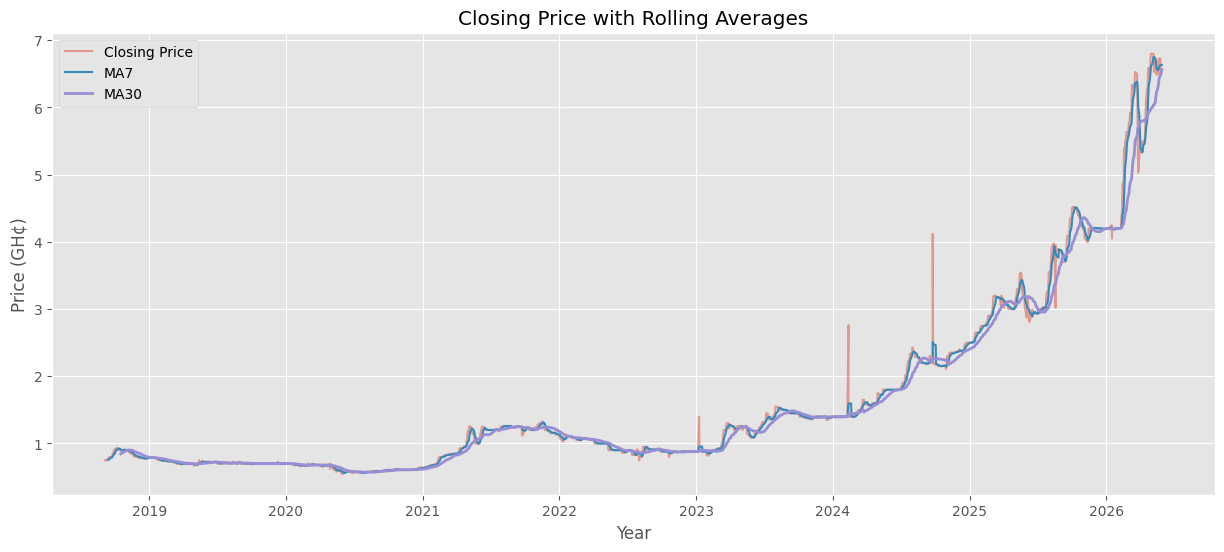

In [88]:
# ===========================================
# Closing Price with Rolling Means
# ===========================================

plt.figure(figsize=(15,6))

plt.plot(
    df_clean["Daily Date"],
    df_clean["Closing Price - VWAP (GH¢)"],
    alpha=0.5,
    label="Closing Price"
)

plt.plot(
    df_clean["Daily Date"],
    df_clean["MA7"],
    label="MA7"
)

plt.plot(
    df_clean["Daily Date"],
    df_clean["MA30"],
    linewidth=2,
    label="MA30"
)

plt.title("Closing Price with Rolling Averages")
plt.xlabel("Year")
plt.ylabel("Price (GH¢)")
plt.legend()

plt.grid(True)

plt.show()

# 4.2 Rolling Statistical Features

## Observation

Rolling statistical features were generated using 7-day, 14-day, and 30-day windows to summarize recent market behaviour. The moving averages smooth short-term fluctuations and reveal the underlying market trend, while the rolling standard deviation quantifies short-term price volatility. Additionally, the rolling minimum and maximum capture the recent trading range over the previous seven trading days.

As expected, the rolling operations introduced missing values at the beginning of the dataset because sufficient historical observations are required before the rolling statistics can be computed.

---

## Interpretation

Rolling statistics provide the forecasting model with contextual information that cannot be obtained from individual observations alone. Moving averages describe the short-, medium-, and long-term market trends, while rolling volatility measures the degree of market uncertainty over recent trading periods. Similarly, the rolling minimum and maximum represent recent support and resistance levels, providing additional information about the local price range.

These engineered features are expected to enhance the predictive performance of the proposed Attention-LSTM model by enabling it to learn both immediate price movements and broader market trends. The missing values introduced by the rolling windows are a natural consequence of the feature engineering process and will be removed after all engineered features have been generated.

#4.3 Momentum Indicators
Objective

Momentum indicators measure the speed, direction, and strength of price movements. Unlike moving averages, which smooth historical prices, momentum features quantify how rapidly prices are changing. These indicators are widely used in technical analysis because they help identify accelerating trends, weakening trends, and potential turning points.

In [89]:
# ===========================================
# 4.3 Daily Return
# ===========================================

df_clean["Daily_Return"] = (
    df_clean["Closing Price - VWAP (GH¢)"]
    .pct_change()
)

df_clean[["Closing Price - VWAP (GH¢)", "Daily_Return"]].head()

,Closing Price - VWAP (GH¢),Daily_Return
0,0.75,NaN
1,0.75,0.000000
2,0.75,0.000000
3,0.75,0.000000
4,0.76,0.013333


In [90]:
# ===========================================
# Log Return
# ===========================================

import numpy as np

df_clean["Log_Return"] = np.log(
    df_clean["Closing Price - VWAP (GH¢)"] /
    df_clean["Closing Price - VWAP (GH¢)"].shift(1)
)

df_clean[["Closing Price - VWAP (GH¢)", "Log_Return"]].head()

,Closing Price - VWAP (GH¢),Log_Return
0,0.75,NaN
1,0.75,0.000000
2,0.75,0.000000
3,0.75,0.000000
4,0.76,0.013245


In [91]:
# ===========================================
# Rate of Change (ROC)
# ===========================================

df_clean["ROC7"] = (
    (
        df_clean["Closing Price - VWAP (GH¢)"] -
        df_clean["Closing Price - VWAP (GH¢)"].shift(7)
    )
    /
    df_clean["Closing Price - VWAP (GH¢)"].shift(7)
) * 100

df_clean[["Closing Price - VWAP (GH¢)", "ROC7"]].tail()

,Closing Price - VWAP (GH¢),ROC7
1894,6.73,3.220859
1895,6.73,3.538462
1896,6.51,0.308166
1897,6.51,0.308166
1898,6.50,-0.459418


In [92]:
# ===========================================
# Momentum
# ===========================================

df_clean["Momentum7"] = (
    df_clean["Closing Price - VWAP (GH¢)"] -
    df_clean["Closing Price - VWAP (GH¢)"].shift(7)
)

df_clean[["Closing Price - VWAP (GH¢)", "Momentum7"]].tail()

,Closing Price - VWAP (GH¢),Momentum7
1894,6.73,0.21
1895,6.73,0.23
1896,6.51,0.02
1897,6.51,0.02
1898,6.50,-0.03


In [93]:
# ===========================================
# Relative Strength Index (RSI)
# ===========================================

window = 14

delta = df_clean["Closing Price - VWAP (GH¢)"].diff()

gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

avg_gain = gain.rolling(window).mean()
avg_loss = loss.rolling(window).mean()

rs = avg_gain / avg_loss

df_clean["RSI14"] = 100 - (100 / (1 + rs))

df_clean[["Closing Price - VWAP (GH¢)", "RSI14"]].tail()

,Closing Price - VWAP (GH¢),RSI14
1894,6.73,46.153846
1895,6.73,46.153846
1896,6.51,37.168142
1897,6.51,38.181818
1898,6.50,48.275862


In [95]:
# ===========================================
# Missing Values
# ===========================================

momentum_cols = [
    "Daily_Return",
    "Log_Return",
    "ROC7",
    "Momentum7",
    "RSI14"
]

df_clean[momentum_cols].isnull().sum()

,0
Daily_Return,1
Log_Return,1
ROC7,7
Momentum7,7
RSI14,141


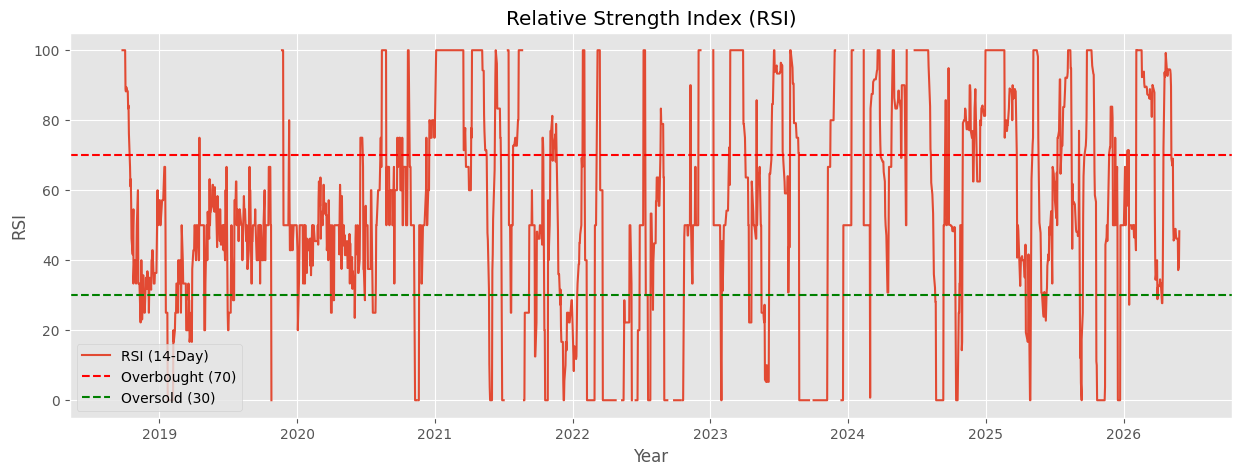

In [96]:
# ===========================================
# RSI Visualization
# ===========================================

plt.figure(figsize=(15,5))

plt.plot(
    df_clean["Daily Date"],
    df_clean["RSI14"],
    label="RSI (14-Day)"
)

plt.axhline(70, linestyle="--", color="red", label="Overbought (70)")
plt.axhline(30, linestyle="--", color="green", label="Oversold (30)")

plt.title("Relative Strength Index (RSI)")
plt.xlabel("Year")
plt.ylabel("RSI")

plt.legend()
plt.grid(True)

plt.show()

# 4.3 Momentum Indicators

## Observation

Momentum-based features were generated to quantify the rate and strength of stock price movements. These include Daily Return, Log Return, 7-day Rate of Change (ROC), 7-day Momentum, and the 14-day Relative Strength Index (RSI). While Daily Return and Log Return capture one-day price changes, ROC and Momentum summarize changes over a seven-day period. RSI measures the balance between recent gains and losses, providing an indication of market momentum.

As expected, these indicators introduced missing values at the beginning of the dataset due to the historical observations required for their calculation.

---

## Interpretation

Momentum indicators provide valuable information regarding the direction and intensity of market movements. Positive values of Daily Return, Log Return, ROC, and Momentum indicate upward price movement, whereas negative values indicate declining prices. The RSI further identifies potential overbought and oversold conditions, which may precede market reversals or periods of consolidation.

These engineered features complement the lag and rolling statistical variables by capturing the dynamics of price changes rather than their absolute values. Consequently, they are expected to improve the forecasting capability of the proposed Attention-LSTM model by enabling it to learn both trend persistence and changes in market momentum.

4.4 Trend Indicators
Objective

Trend indicators identify the underlying direction of the market over different time horizons. Unlike simple moving averages, Exponential Moving Averages (EMAs) assign greater weight to recent prices, allowing them to respond more quickly to market changes. The Moving Average Convergence Divergence (MACD) indicator combines multiple EMAs to capture changes in trend strength and momentum.

In [97]:
# ===========================================
# 4.4 Exponential Moving Averages
# ===========================================

df_clean["EMA12"] = (
    df_clean["Closing Price - VWAP (GH¢)"]
    .ewm(span=12, adjust=False)
    .mean()
)

df_clean["EMA26"] = (
    df_clean["Closing Price - VWAP (GH¢)"]
    .ewm(span=26, adjust=False)
    .mean()
)

df_clean[["Closing Price - VWAP (GH¢)", "EMA12", "EMA26"]].tail()

,Closing Price - VWAP (GH¢),EMA12,EMA26
1894,6.73,6.620891,6.474482
1895,6.73,6.637677,6.493410
1896,6.51,6.618035,6.494639
1897,6.51,6.601414,6.495776
1898,6.50,6.585812,6.496089


In [98]:
# ===========================================
# Moving Average Convergence Divergence
# ===========================================

df_clean["MACD"] = df_clean["EMA12"] - df_clean["EMA26"]

df_clean[["MACD"]].tail()

,MACD
1894,0.146409
1895,0.144268
1896,0.123396
1897,0.105637
1898,0.089722


In [99]:
# ===========================================
# MACD Signal
# ===========================================

df_clean["MACD_Signal"] = (
    df_clean["MACD"]
    .ewm(span=9, adjust=False)
    .mean()
)

df_clean[["MACD", "MACD_Signal"]].tail()

,MACD,MACD_Signal
1894,0.146409,0.173994
1895,0.144268,0.168049
1896,0.123396,0.159118
1897,0.105637,0.148422
1898,0.089722,0.136682


In [100]:
# ===========================================
# MACD Histogram
# ===========================================

df_clean["MACD_Histogram"] = (
    df_clean["MACD"] -
    df_clean["MACD_Signal"]
)

df_clean[["MACD", "MACD_Signal", "MACD_Histogram"]].tail()

,MACD,MACD_Signal,MACD_Histogram
1894,0.146409,0.173994,-0.027585
1895,0.144268,0.168049,-0.023781
1896,0.123396,0.159118,-0.035722
1897,0.105637,0.148422,-0.042785
1898,0.089722,0.136682,-0.046960


In [101]:
# ===========================================
# Missing Values
# ===========================================

trend_cols = [
    "EMA12",
    "EMA26",
    "MACD",
    "MACD_Signal",
    "MACD_Histogram"
]

df_clean[trend_cols].isnull().sum()

,0
EMA12,0
EMA26,0
MACD,0
MACD_Signal,0
MACD_Histogram,0


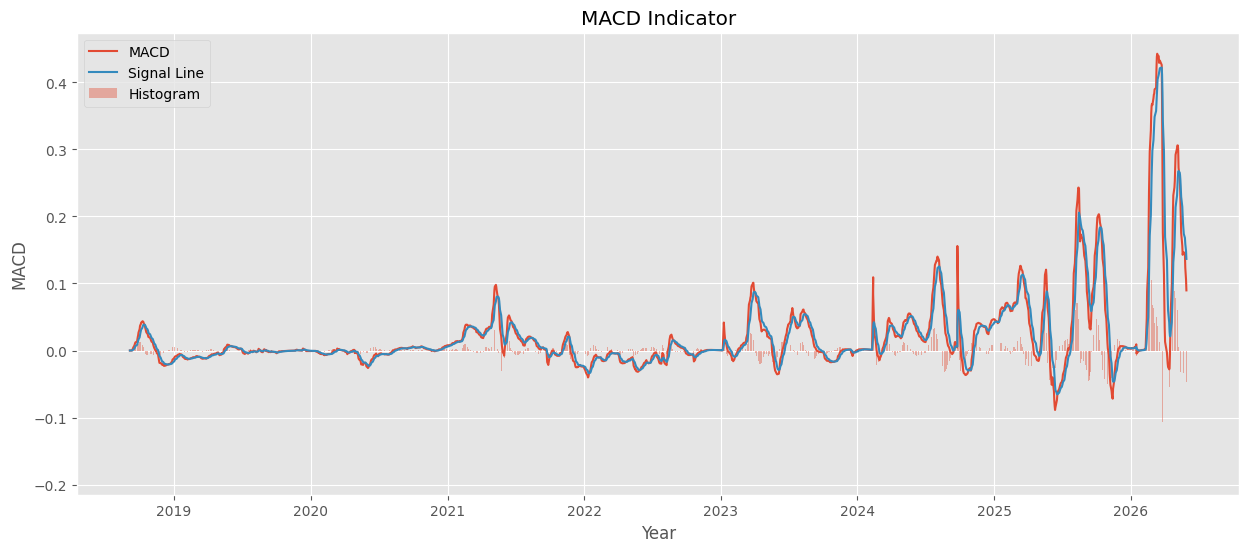

In [102]:
# ===========================================
# MACD Chart
# ===========================================

plt.figure(figsize=(15,6))

plt.plot(
    df_clean["Daily Date"],
    df_clean["MACD"],
    label="MACD"
)

plt.plot(
    df_clean["Daily Date"],
    df_clean["MACD_Signal"],
    label="Signal Line"
)

plt.bar(
    df_clean["Daily Date"],
    df_clean["MACD_Histogram"],
    alpha=0.4,
    label="Histogram"
)

plt.title("MACD Indicator")
plt.xlabel("Year")
plt.ylabel("MACD")

plt.legend()

plt.grid(True)

plt.show()

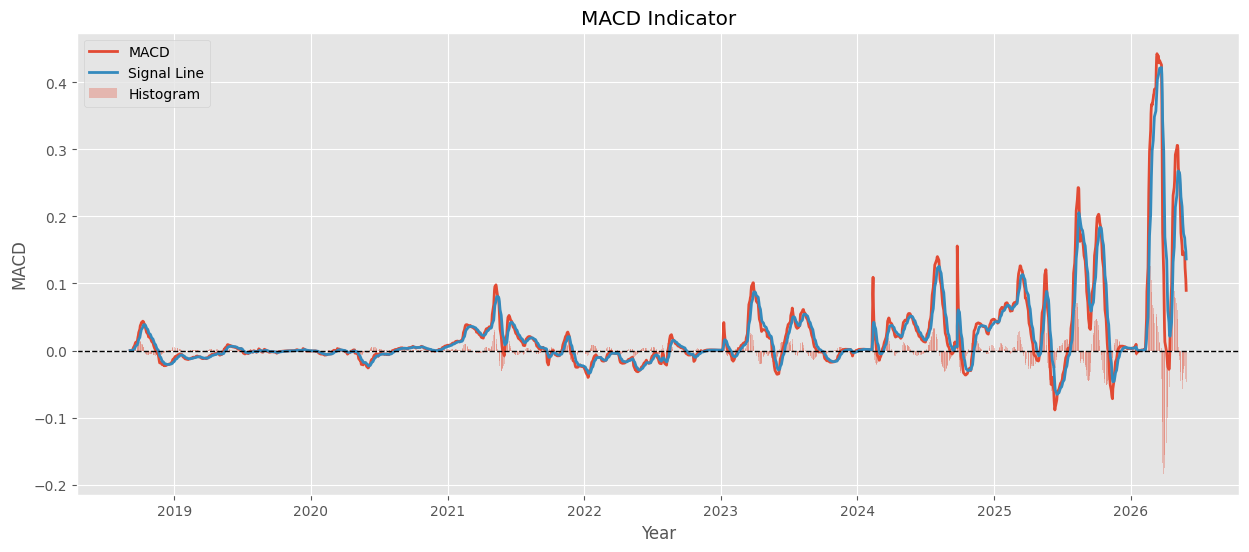

In [103]:
plt.figure(figsize=(15,6))

plt.plot(
    df_clean["Daily Date"],
    df_clean["MACD"],
    linewidth=2,
    label="MACD"
)

plt.plot(
    df_clean["Daily Date"],
    df_clean["MACD_Signal"],
    linewidth=2,
    label="Signal Line"
)

plt.bar(
    df_clean["Daily Date"],
    df_clean["MACD_Histogram"],
    width=2,
    alpha=0.3,
    label="Histogram"
)

plt.axhline(0, color="black", linestyle="--", linewidth=1)

plt.title("MACD Indicator")
plt.xlabel("Year")
plt.ylabel("MACD")
plt.legend()
plt.grid(True)

plt.show()

## Observation

The MACD indicator fluctuates around the zero reference line throughout the study period, with relatively small oscillations between 2018 and 2022. From 2023 onwards, both the MACD and Signal Line exhibit larger fluctuations, indicating stronger trend dynamics and increasing market activity. The highest positive MACD values occur during 2025 and early 2026, corresponding to periods of sustained price appreciation. Similarly, the MACD Histogram displays larger positive and negative bars during the latter part of the study period, reflecting stronger bullish and bearish momentum compared to the earlier years.

---

## Interpretation

The MACD and Signal Line provide complementary information regarding changes in market trend and momentum. Positive MACD values indicate that the short-term exponential moving average exceeds the long-term exponential moving average, suggesting bullish market conditions, whereas negative values indicate bearish momentum. Crossovers between the MACD and Signal Line highlight potential changes in market direction, while the Histogram measures the strength of these movements by illustrating the divergence between the two indicators.

The increasing amplitude of the MACD observed during 2025–2026 is consistent with the strong upward price trend and heightened market volatility identified in the exploratory data analysis. These findings indicate that the stock experienced more pronounced directional movements in the latter years of the study period. Consequently, the MACD-based features are expected to enhance the predictive capability of the proposed Attention-LSTM model by providing additional information on trend persistence, momentum shifts, and changes in market dynamics that are not captured by raw price observations alone.

4.5 Volatility Indicators
Objective

Volatility indicators quantify the degree of price fluctuation over time and provide information about market uncertainty. Unlike trend indicators that describe the direction of price movement, volatility indicators measure the magnitude of price changes. These features are particularly useful in financial forecasting because periods of high volatility often precede significant market movements.

In [104]:
# ===========================================
# 4.5 Rolling Volatility
# ===========================================

df_clean["Rolling_Volatility30"] = (
    df_clean["Closing Price - VWAP (GH¢)"]
    .rolling(window=30)
    .std()
)

df_clean[["Closing Price - VWAP (GH¢)", "Rolling_Volatility30"]].tail()

,Closing Price - VWAP (GH¢),Rolling_Volatility30
1894,6.73,0.398145
1895,6.73,0.360246
1896,6.51,0.309698
1897,6.51,0.251410
1898,6.50,0.208053


In [105]:
# ===========================================
# Bollinger Bands
# ===========================================

rolling_mean = (
    df_clean["Closing Price - VWAP (GH¢)"]
    .rolling(window=20)
    .mean()
)

rolling_std = (
    df_clean["Closing Price - VWAP (GH¢)"]
    .rolling(window=20)
    .std()
)

df_clean["BB_Upper"] = rolling_mean + (2 * rolling_std)

df_clean["BB_Lower"] = rolling_mean - (2 * rolling_std)

In [106]:
# ===========================================
# Bollinger Band Width
# ===========================================

df_clean["BB_Width"] = (
    df_clean["BB_Upper"] -
    df_clean["BB_Lower"]
)

df_clean[["BB_Upper", "BB_Lower", "BB_Width"]].tail()

,BB_Upper,BB_Lower,BB_Width
1894,6.897429,6.398571,0.498858
1895,6.905159,6.406841,0.498317
1896,6.905159,6.406841,0.498317
1897,6.907348,6.400652,0.506696
1898,6.896582,6.384418,0.512164


In [107]:
# ===========================================
# Missing Values
# ===========================================

volatility_cols = [
    "Rolling_Volatility30",
    "BB_Upper",
    "BB_Lower",
    "BB_Width"
]

df_clean[volatility_cols].isnull().sum()

,0
Rolling_Volatility30,29
BB_Upper,19
BB_Lower,19
BB_Width,19


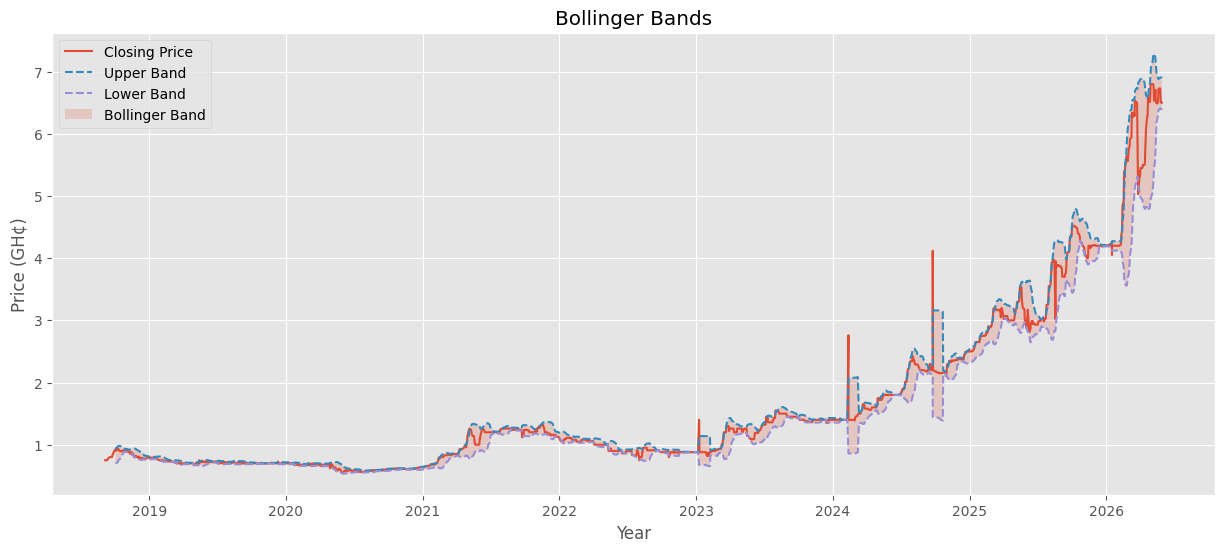

In [108]:
# ===========================================
# Bollinger Bands
# ===========================================

plt.figure(figsize=(15,6))

plt.plot(
    df_clean["Daily Date"],
    df_clean["Closing Price - VWAP (GH¢)"],
    label="Closing Price",
    linewidth=1.5
)

plt.plot(
    df_clean["Daily Date"],
    df_clean["BB_Upper"],
    linestyle="--",
    label="Upper Band"
)

plt.plot(
    df_clean["Daily Date"],
    df_clean["BB_Lower"],
    linestyle="--",
    label="Lower Band"
)

plt.fill_between(
    df_clean["Daily Date"],
    df_clean["BB_Lower"],
    df_clean["BB_Upper"],
    alpha=0.2,
    label="Bollinger Band"
)

plt.title("Bollinger Bands")
plt.xlabel("Year")
plt.ylabel("Price (GH¢)")
plt.legend()
plt.grid(True)

plt.show()

## Observation

The Bollinger Bands closely follow the movement of the closing price throughout the study period. Between 2018 and 2022, the bands remain relatively narrow, indicating relatively low price variability and stable market conditions. From 2023 onwards, the bands gradually widen, with the most pronounced expansion occurring during 2025 and early 2026. During this period, the closing price frequently approaches the upper Bollinger Band, reflecting stronger upward price movements and increased market activity.

The shaded region between the upper and lower Bollinger Bands expands during periods of heightened volatility and contracts during relatively stable periods, demonstrating the effectiveness of the indicator in capturing changes in market uncertainty over time.

---

## Interpretation

Bollinger Bands provide a dynamic measure of market volatility by combining a moving average with upper and lower volatility boundaries. Narrow bands indicate periods of relatively stable price movements, whereas wider bands signify increased market uncertainty and larger price fluctuations. The expansion of the Bollinger Bands observed during 2025 and early 2026 aligns with the higher market volatility identified in the rolling volatility and MACD analyses, confirming that the stock experienced stronger and more persistent price movements during the latter part of the study period.

Furthermore, the tendency of the closing price to remain close to the upper Bollinger Band during this period suggests sustained bullish momentum rather than isolated price spikes. Together with the rolling volatility feature, the Bollinger Bands provide valuable information about changes in market dynamics that complement the lag, momentum, and trend indicators. These volatility-based features are expected to enhance the predictive performance of the proposed Attention-LSTM model by enabling it to learn both stable market conditions and periods of elevated uncertainty.

4.6 Calendar Features
Objective

Calendar features capture temporal patterns associated with different periods of the year. Although the EDA showed only weak weekday effects, yearly and monthly analyses indicated changing market behaviour over time. These variables allow the model to learn recurring seasonal patterns and long-term temporal effects that may not be captured by price-based indicators alone.

In [109]:
# ===========================================
# 4.6 Calendar Features
# ===========================================

# Ensure the date column is in datetime format
df_clean["Daily Date"] = pd.to_datetime(df_clean["Daily Date"])

# Extract calendar features
df_clean["Year"] = df_clean["Daily Date"].dt.year
df_clean["Month"] = df_clean["Daily Date"].dt.month
df_clean["Quarter"] = df_clean["Daily Date"].dt.quarter
df_clean["Day_of_Week"] = df_clean["Daily Date"].dt.dayofweek

# Display sample
df_clean[["Daily Date", "Year", "Month", "Quarter", "Day_of_Week"]].head()

,Daily Date,Year,Month,Quarter,Day_of_Week
0,2018-09-05,2018,9,3,2
1,2018-09-06,2018,9,3,3
2,2018-09-07,2018,9,3,4
3,2018-09-10,2018,9,3,0
4,2018-09-11,2018,9,3,1


In [110]:
# ===========================================
# Missing Values
# ===========================================

calendar_cols = [
    "Year",
    "Month",
    "Quarter",
    "Day_of_Week"
]

df_clean[calendar_cols].isnull().sum()

,0
Year,0
Month,0
Quarter,0
Day_of_Week,0


In [111]:
# ===========================================
# Check Calendar Features
# ===========================================

df_clean[calendar_cols].describe()

,Year,Month,Quarter,Day_of_Week
count,1899.000000,1899.000000,1899.000000,1899.000000
mean,2022.040021,6.515008,2.510269,2.008425
std,2.273103,3.489886,1.134884,1.400336
min,2018.000000,1.000000,1.000000,0.000000
25%,2020.000000,3.000000,1.000000,1.000000
50%,2022.000000,7.000000,3.000000,2.000000
75%,2024.000000,10.000000,4.000000,3.000000
max,2026.000000,12.000000,4.000000,4.000000


## Observation

The descriptive statistics confirm that the calendar features were successfully extracted from the trading date without introducing missing values. The dataset spans the period from **2018 to 2026**, with observations distributed across all twelve months, four quarters, and the five trading weekdays (Monday to Friday).

The mean year of approximately **2022** indicates that the observations are well distributed throughout the study period. Similarly, the average month (6.52) and quarter (2.51) suggest that the dataset covers the trading calendar uniformly, while the average day-of-week value (2.01) indicates that trading records are reasonably balanced across weekdays.

---

## Interpretation

The extracted calendar features provide temporal information that complements the technical indicators derived from historical prices. Unlike lagged, momentum, trend, and volatility features, these variables describe the timing of each observation rather than the market behaviour itself. Consequently, they enable the forecasting model to identify long-term temporal trends, seasonal effects, quarterly variations, and potential weekday trading patterns.

The balanced distribution of observations across years, months, quarters, and weekdays ensures that these temporal variables provide sufficient information for the proposed Attention-LSTM model to learn recurring market patterns without introducing temporal bias. Together with the engineered technical indicators, these calendar features contribute to a comprehensive representation of the stock market dynamics throughout the study period.